In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py

# Rename files to SAMPLE format

In [5]:
# import re
# from pathlib import Path

# def pad_field(filename: str, field: str, width: int = 3) -> str:
#     """Zero-pad the number following `field_` to `width` digits."""
#     pattern = rf"({field}_)(\d+)"
#     def repl(m):
#         return m.group(1) + m.group(2).zfill(width)
#     return re.sub(pattern, repl, filename)

# def rename_all(root_dir, dry_run=True):
#     root = Path(root_dir)
#     renamed = []
#     for npy_path in root.rglob("*.npy"):
#         old_name = npy_path.name
#         new_name = pad_field(old_name, "elevDeg")
#         new_name = pad_field(new_name, "azCenter")
        
#         if new_name != old_name:
#             new_path = npy_path.with_name(new_name)
#             renamed.append((npy_path, new_path))
#             if not dry_run:
#                 npy_path.rename(new_path)
    
#     return renamed

# # Dry run first — check the mapping looks right before actually renaming
# root_dir = r"/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files"
# changes = rename_all(root_dir, dry_run=False)
# print(f"{len(changes)} files would be renamed")
# for old, new in changes[:10]:
#     print(f"{old.name} -> {new.name}")

19332 files would be renamed
2s1_real_elevDeg_15_azCenter_0_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_000_sn_b01.npy
2s1_real_elevDeg_15_azCenter_100_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_100_sn_b01.npy
2s1_real_elevDeg_15_azCenter_101_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_101_sn_b01.npy
2s1_real_elevDeg_15_azCenter_103_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_103_sn_b01.npy
2s1_real_elevDeg_15_azCenter_104_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_104_sn_b01.npy
2s1_real_elevDeg_15_azCenter_105_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_105_sn_b01.npy
2s1_real_elevDeg_15_azCenter_106_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_106_sn_b01.npy
2s1_real_elevDeg_15_azCenter_108_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_108_sn_b01.npy
2s1_real_elevDeg_15_azCenter_109_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_109_sn_b01.npy
2s1_real_elevDeg_15_azCenter_10_sn_b01.npy -> 2s1_real_elevDeg_015_azCenter_010_sn_b01.npy


# Masking 

In [2]:
no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

meas_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real",
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

## Precomputed Masks

In [3]:
def get_mask_path(img_path, npy_root, mask_root):
    """
    Map a sample path under npy_noscaling_files/... to its corresponding
    mask path under masks/npy_files/...
    """
    img_path = Path(img_path)
    npy_root = Path(npy_root)
    mask_root = Path(mask_root)
    
    rel_path = img_path.relative_to(npy_root)  # e.g. real/2s1/2s1_real_..._b01.npy
    return mask_root / rel_path

In [10]:
npy_root = "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files"
mask_root = "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/masks/npy_files"

synth_paths = [s[0] for s in no_aug_synth_ds.samples]
synth_target_cache = {}

for path in tqdm(synth_paths):
    mask_path = get_mask_path(path, npy_root, mask_root)
    mask = np.load(mask_path)
    synth_target_cache[path] = mask.astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]
meas_target_cache = {}

for path in tqdm(meas_paths):
    mask_path = get_mask_path(path, npy_root, mask_root)
    mask = np.load(mask_path)
    meas_target_cache[path] = mask.astype(np.uint8)

100%|████████████████████████████████████████████████████████████████████████████| 13932/13932 [02:01<00:00, 114.38it/s]


In [11]:
precomputed_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

precomputed_target_meas_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

## Zhao Masking

In [16]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

zhao_synth_target_cache = {}
for path in tqdm(synth_paths):
    img = dso_np_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img, high_val = 97)
    zhao_synth_target_cache[path] = (T).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

zhao_meas_target_cache = {}
for path in tqdm(meas_paths):
    img = dso_np_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img, high_val = 97)
    zhao_meas_target_cache[path] = (T).astype(np.uint8)

100%|█████████████████████████████████████████████████████████████████████████████| 13932/13932 [11:51<00:00, 19.59it/s]


In [25]:
zhao_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=zhao_synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

zhao_target_meas_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=zhao_meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

## Plotting

In [27]:
np.sort(np.random.choice(13932, size = 100, replace = False))

array([  154,   204,   248,   281,   485,   560,  1002,  1071,  1187,
        1313,  1566,  1666,  1878,  2004,  2050,  2262,  2330,  2392,
        2571,  2675,  2706,  2792,  2887,  2893,  2903,  3178,  3182,
        3555,  3556,  3769,  4174,  4197,  4660,  4826,  4994,  5126,
        5178,  5199,  5241,  5361,  5433,  5512,  5542,  5745,  5763,
        5795,  5887,  5938,  6217,  6292,  6402,  6632,  6635,  7069,
        7149,  7154,  7226,  7263,  7273,  7568,  7796,  7809,  7821,
        8113,  8164,  8477,  8896,  9311,  9335,  9430,  9513,  9651,
        9664,  9697,  9699, 10141, 10148, 10281, 10311, 10389, 10474,
       10485, 10668, 10778, 10855, 11035, 11263, 11331, 11341, 11376,
       11431, 11706, 11997, 12034, 12472, 12548, 12559, 12687, 12937,
       13862])

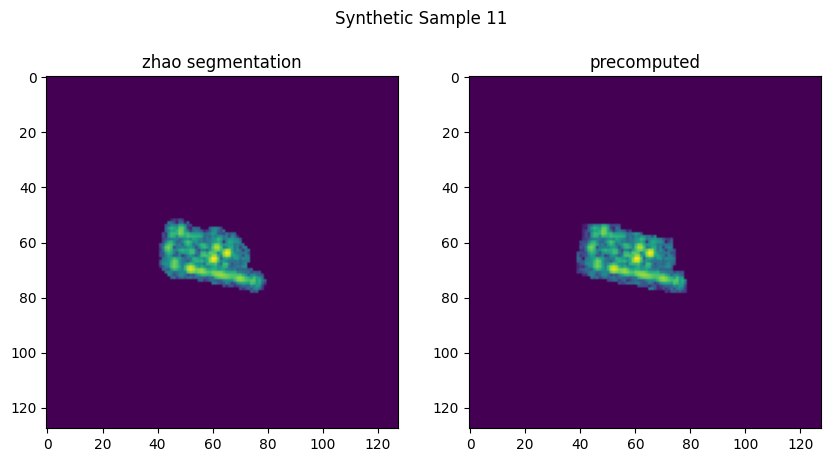

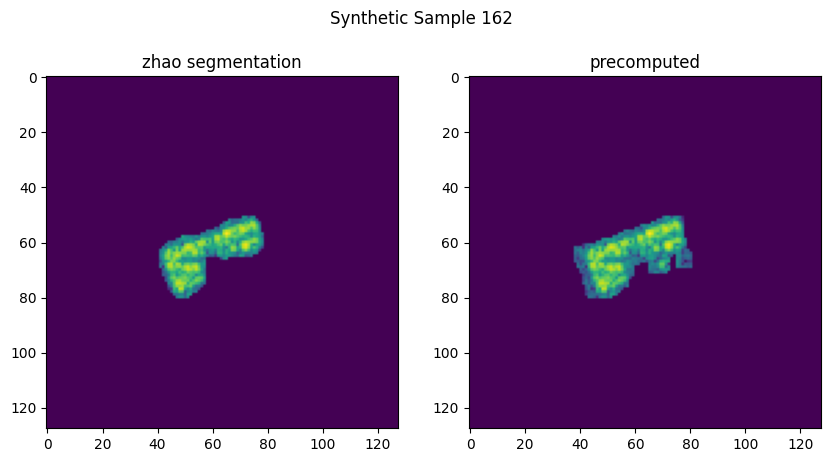

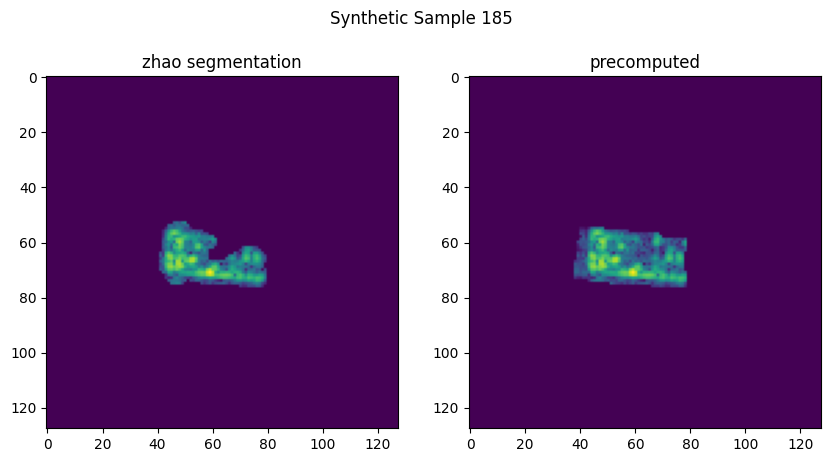

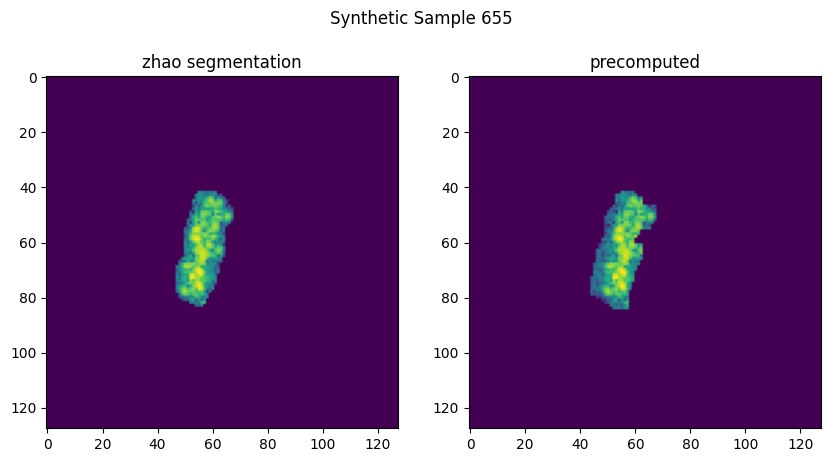

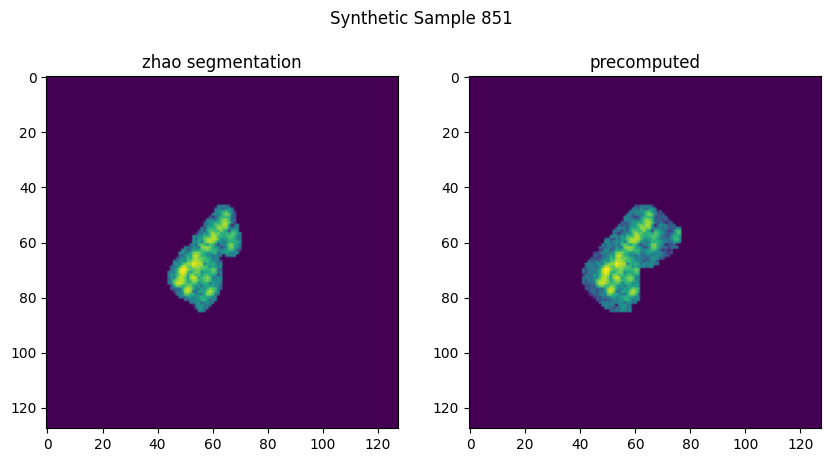

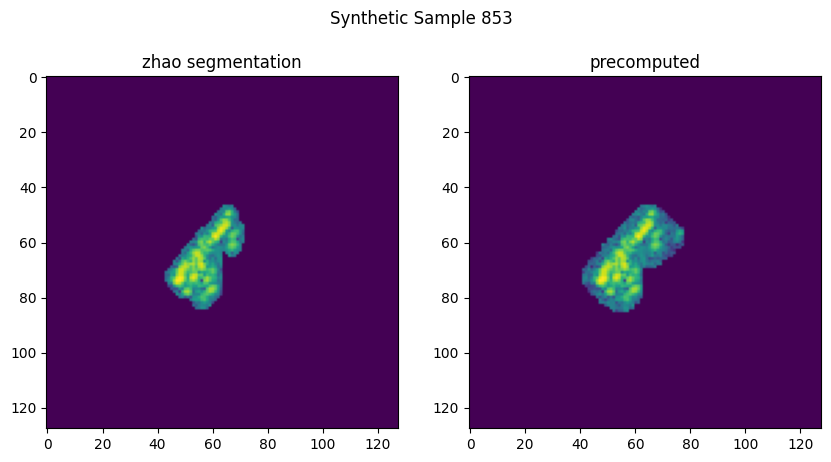

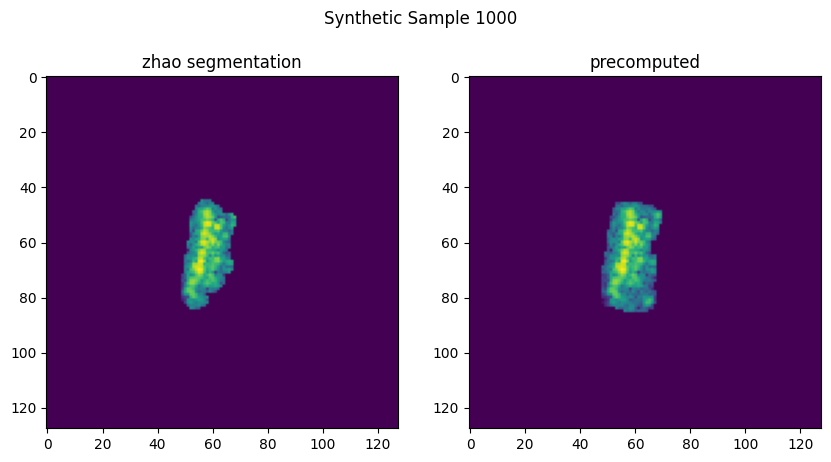

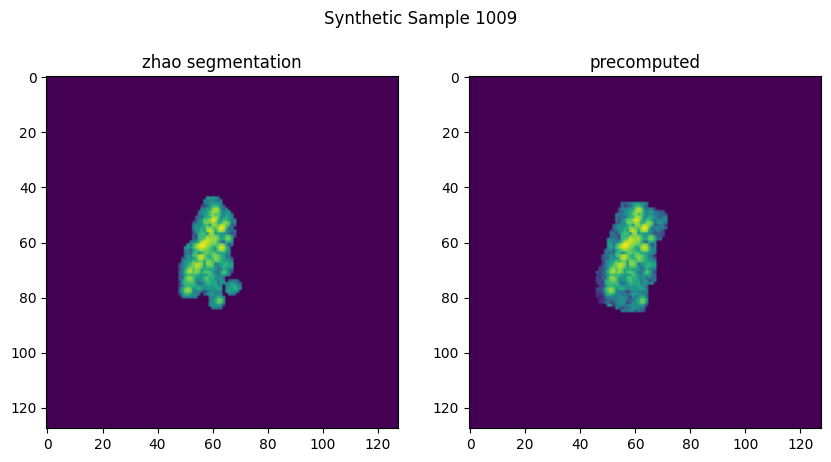

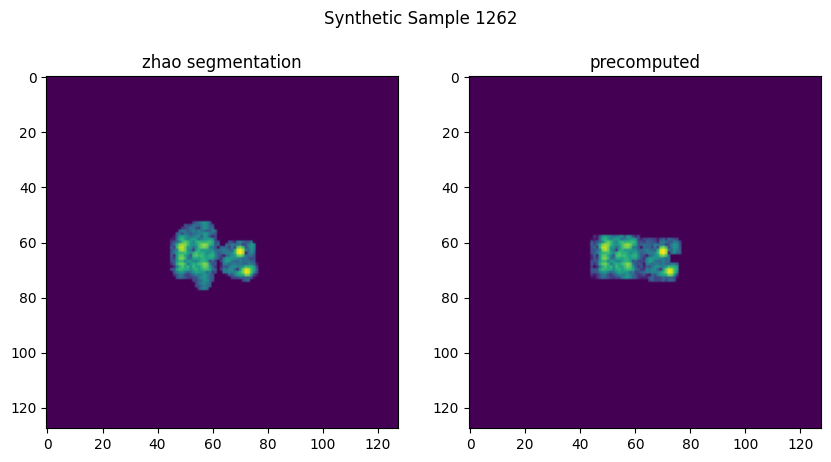

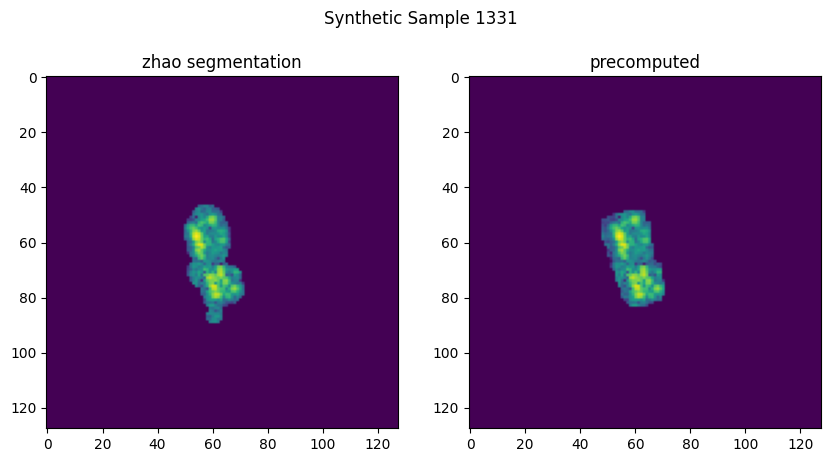

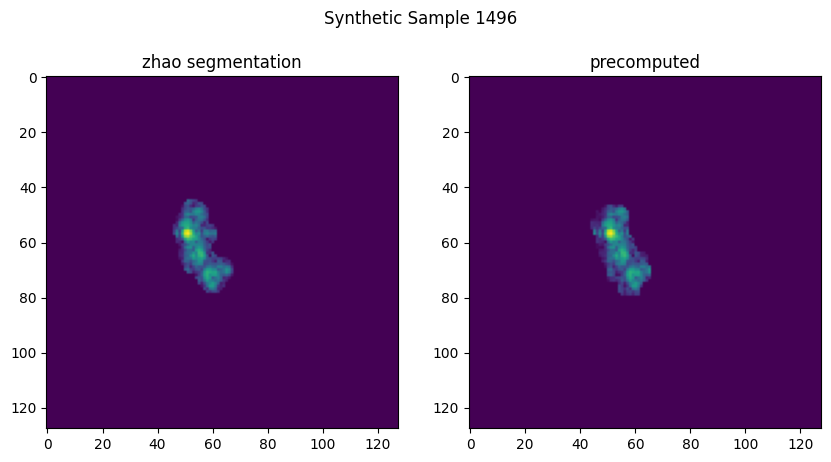

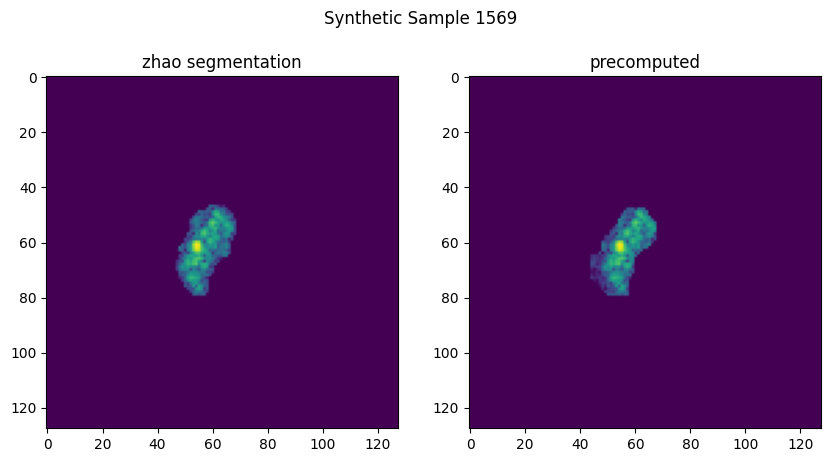

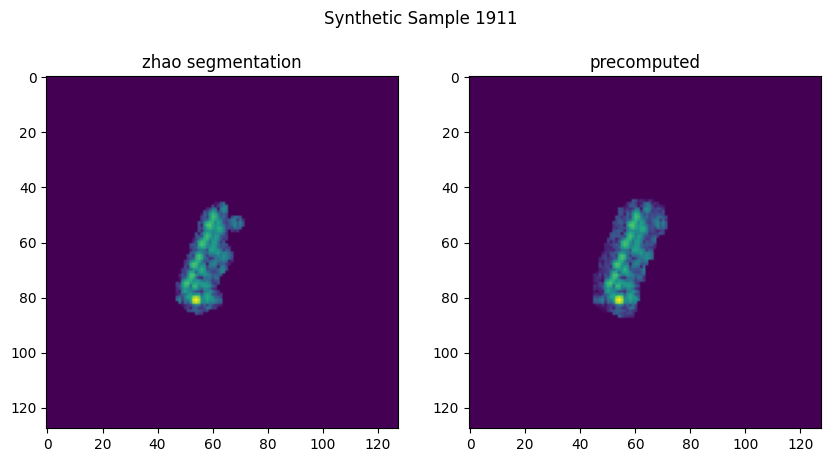

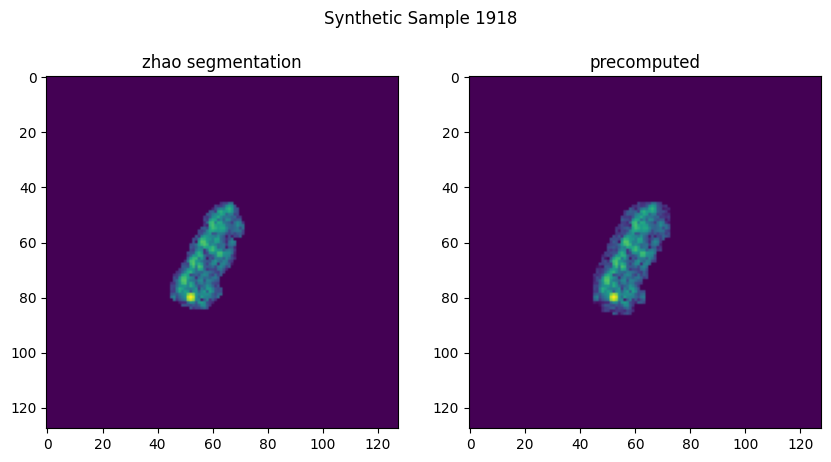

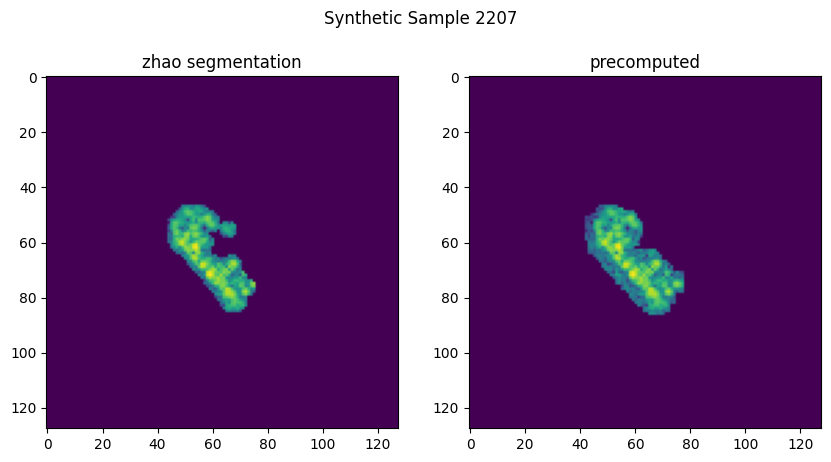

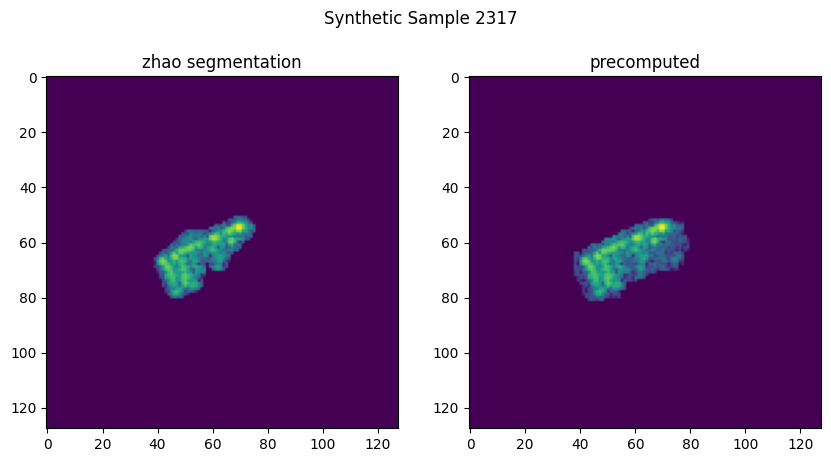

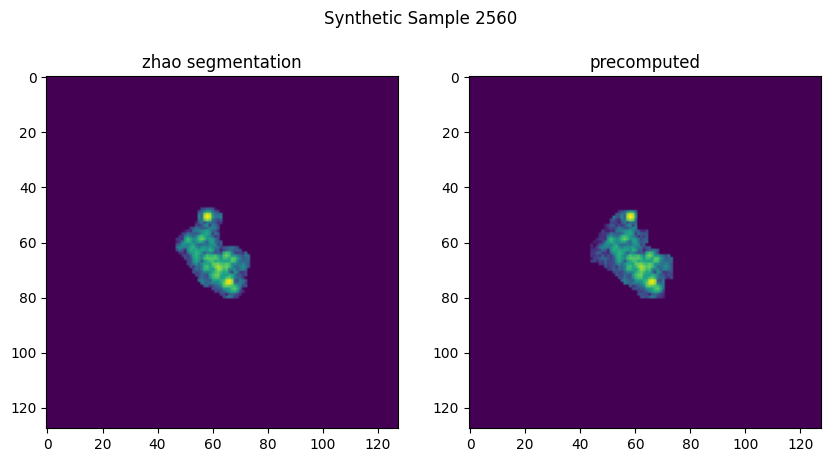

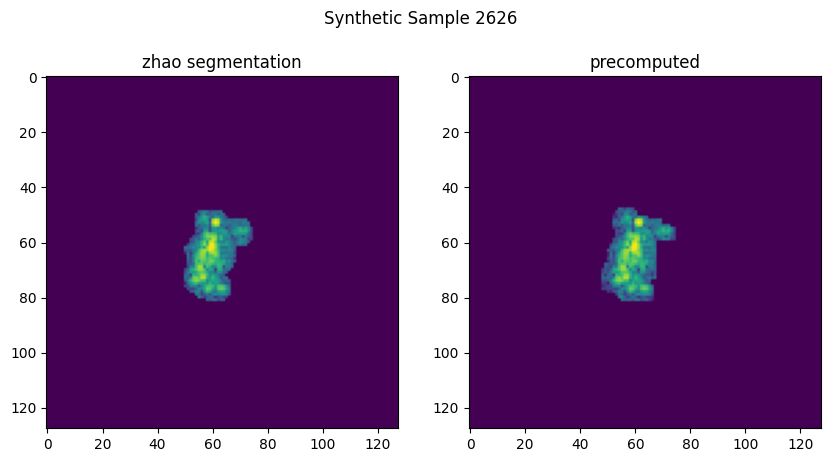

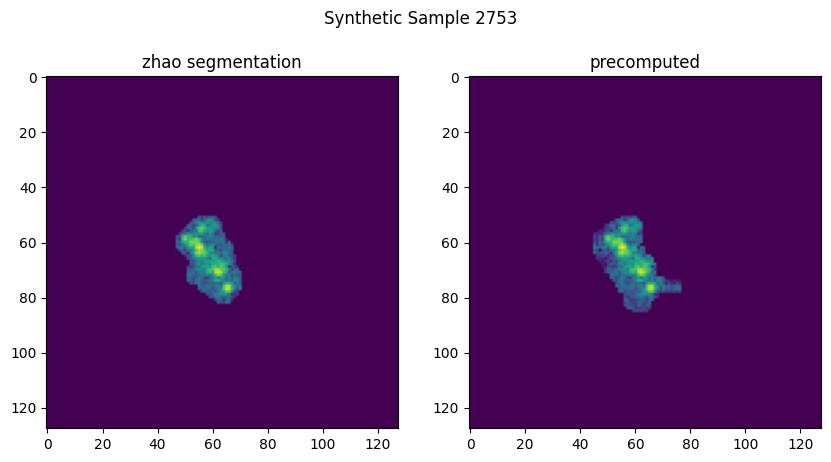

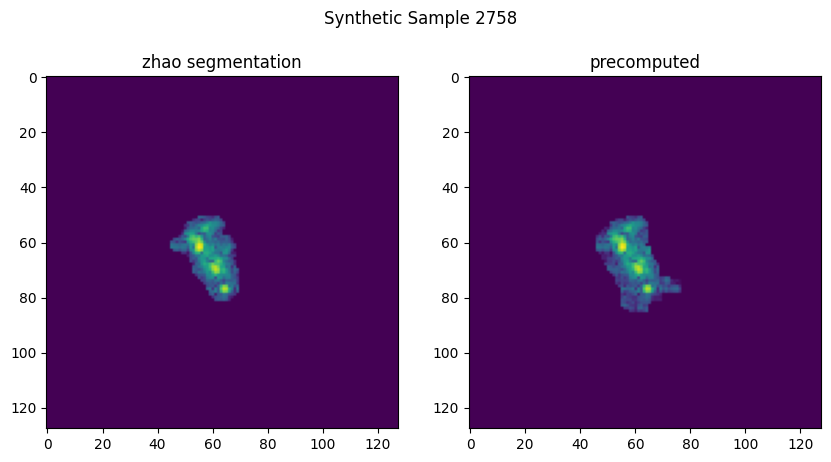

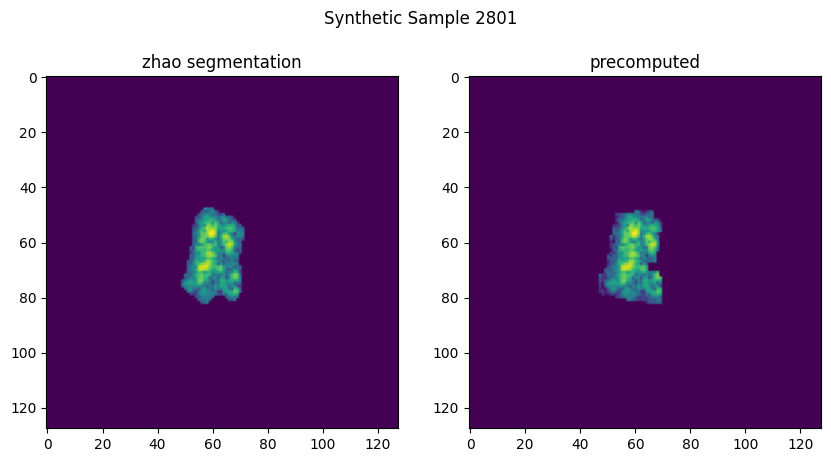

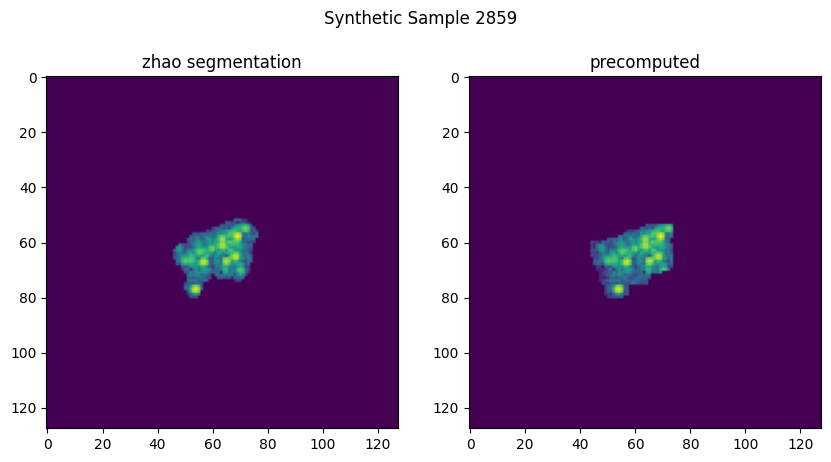

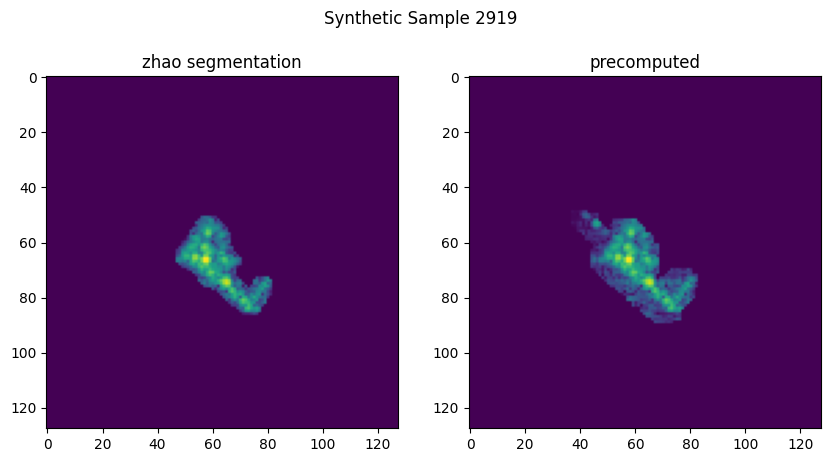

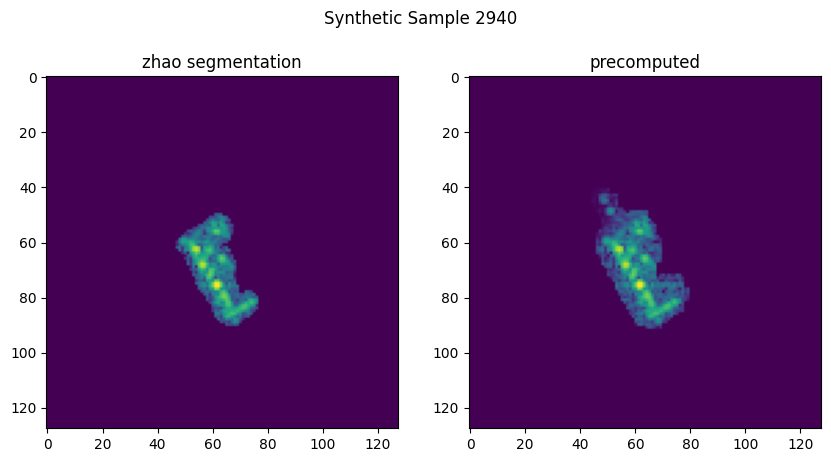

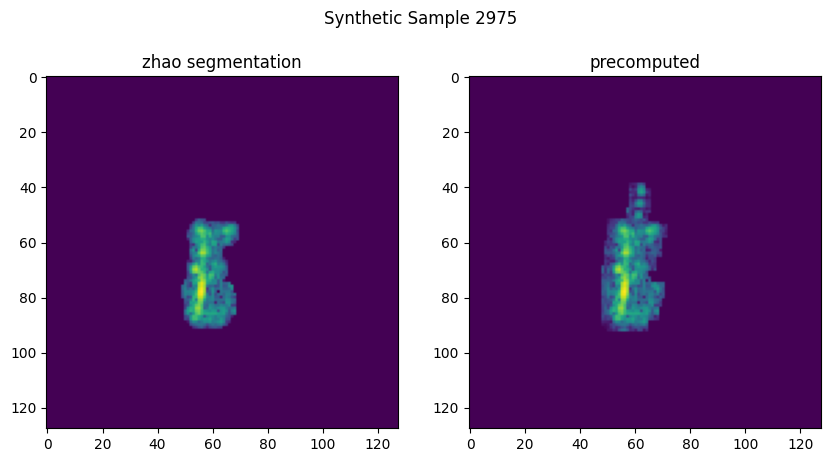

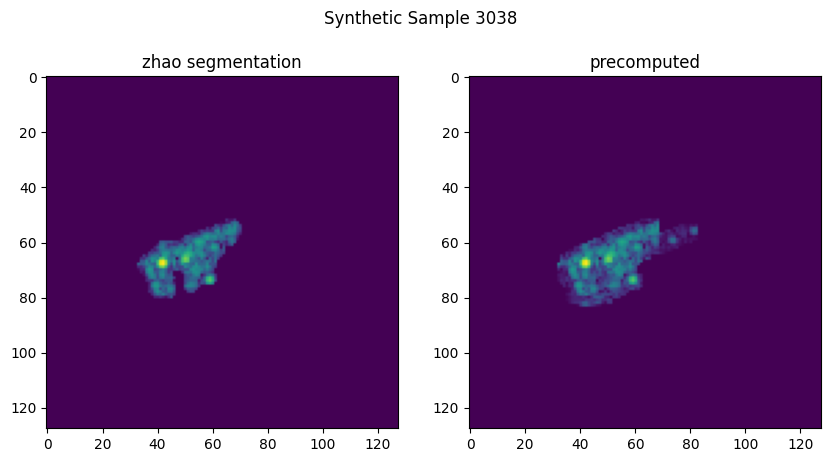

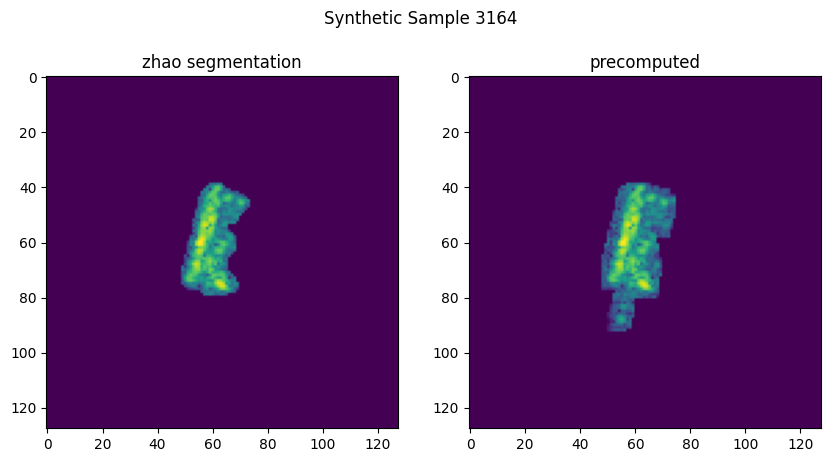

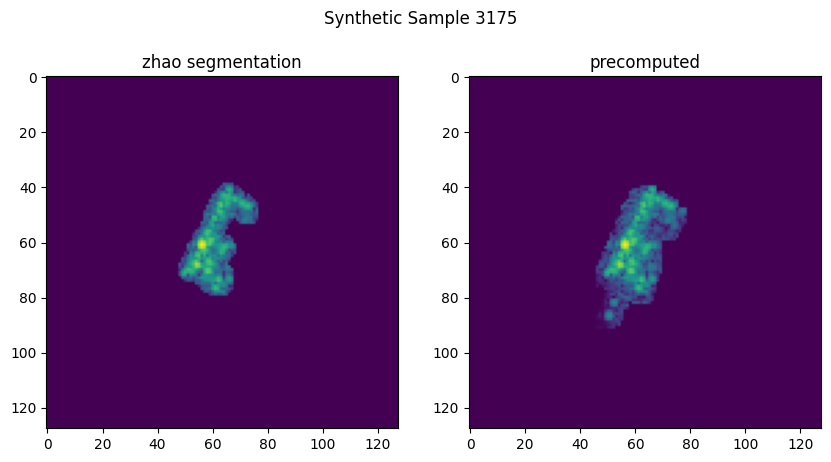

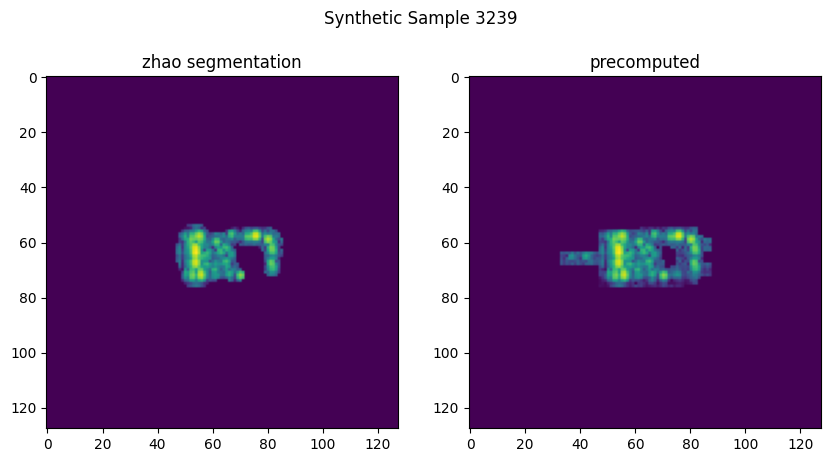

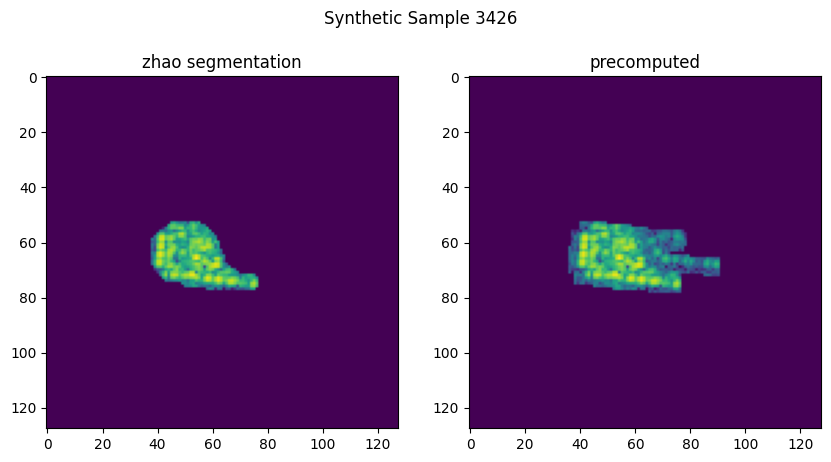

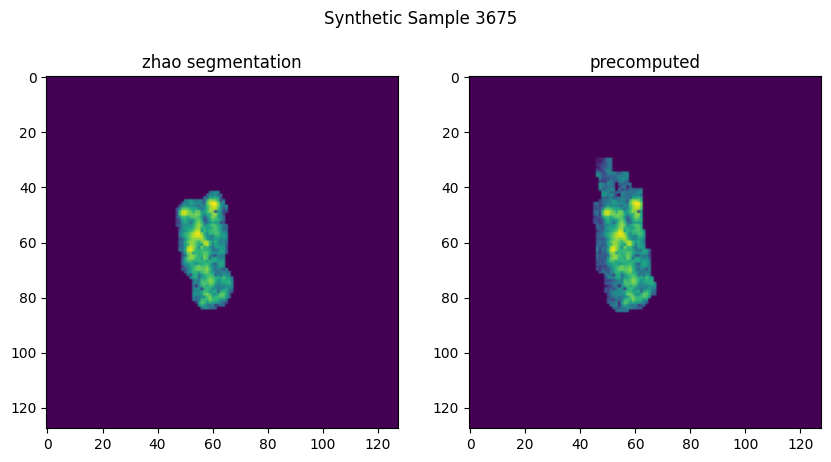

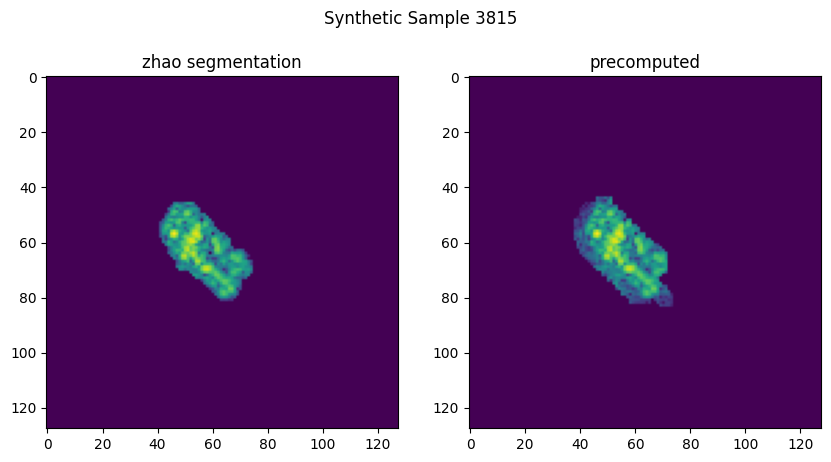

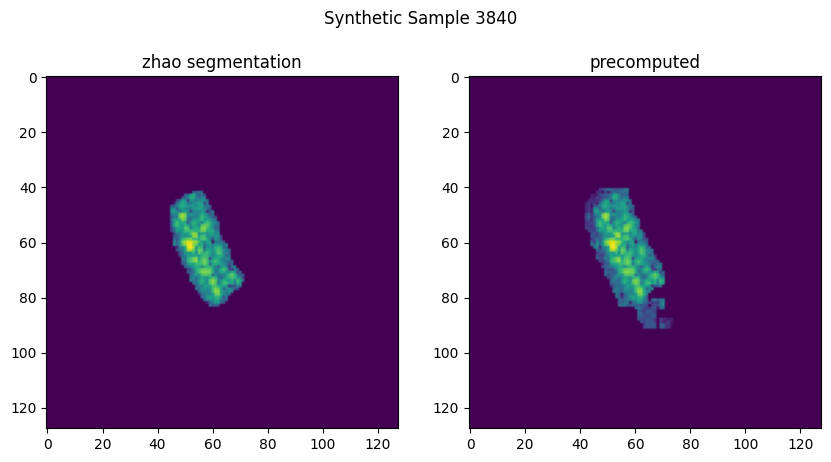

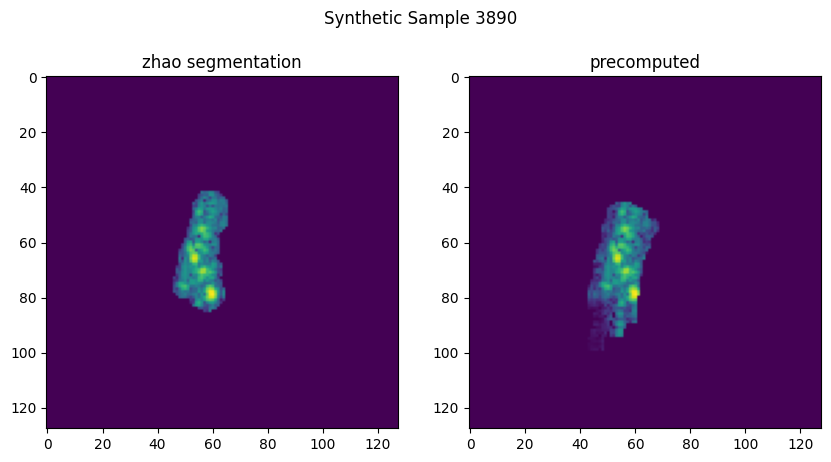

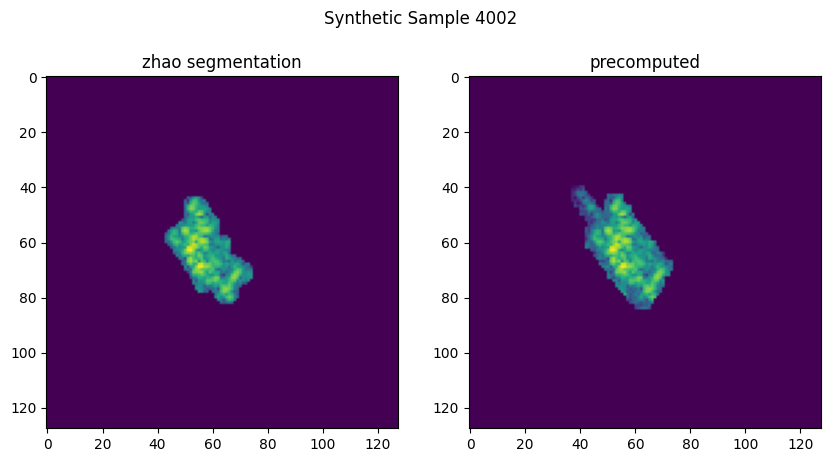

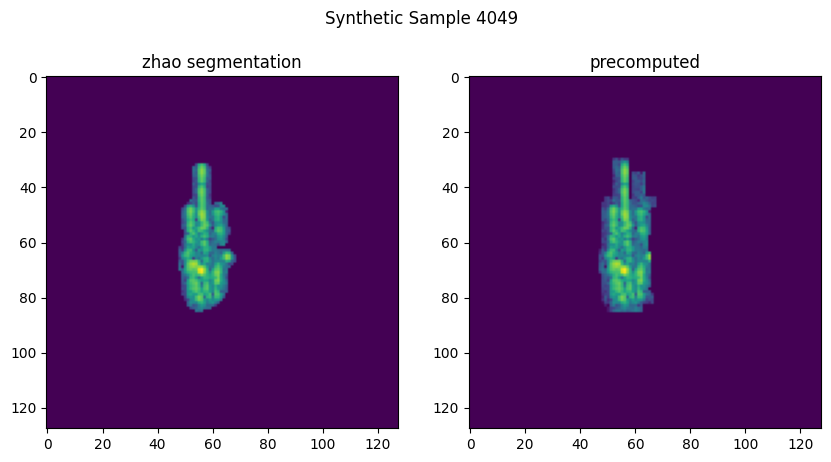

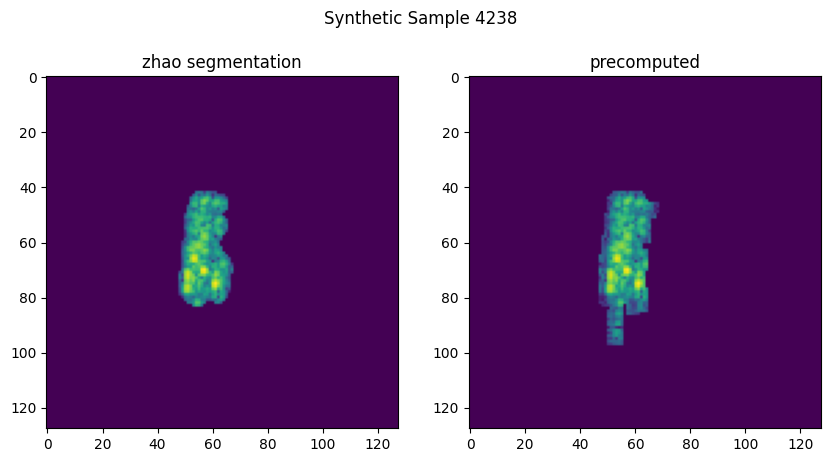

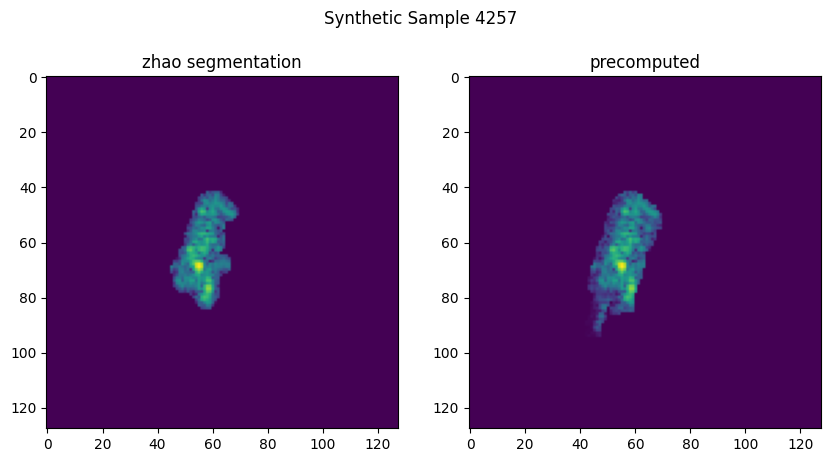

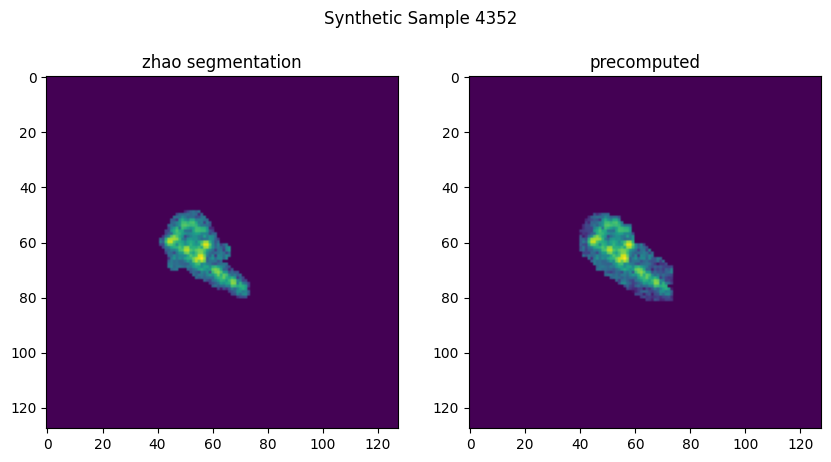

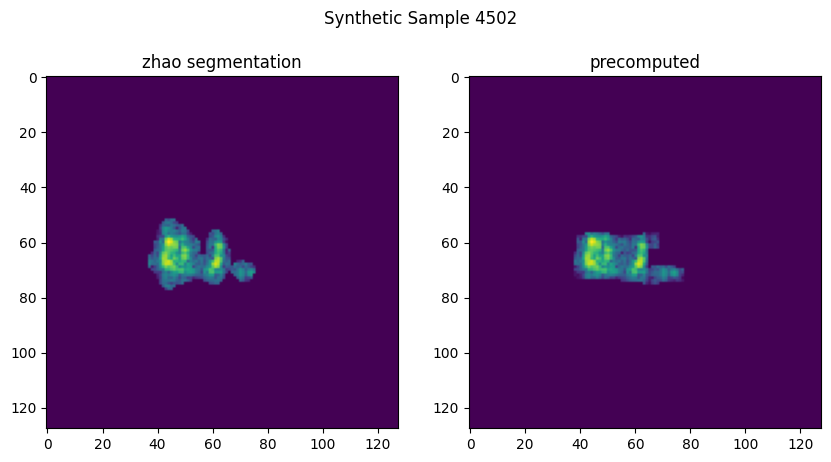

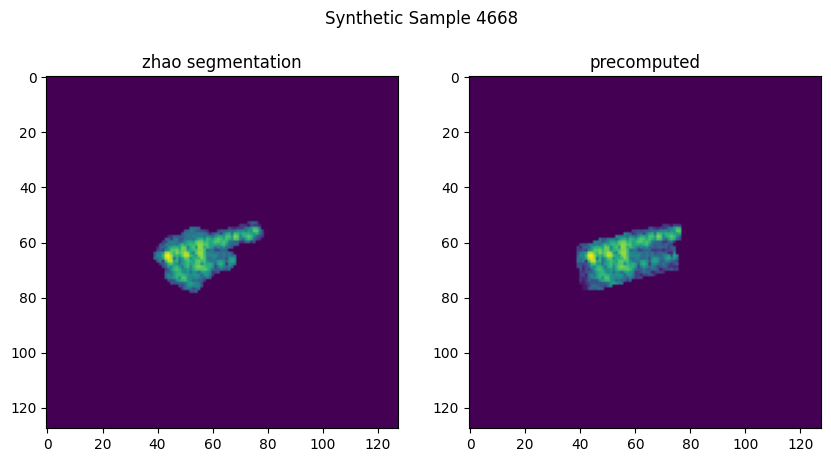

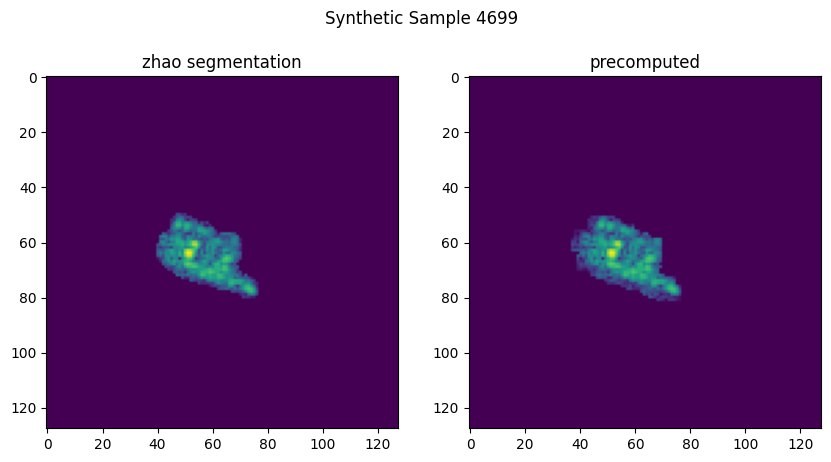

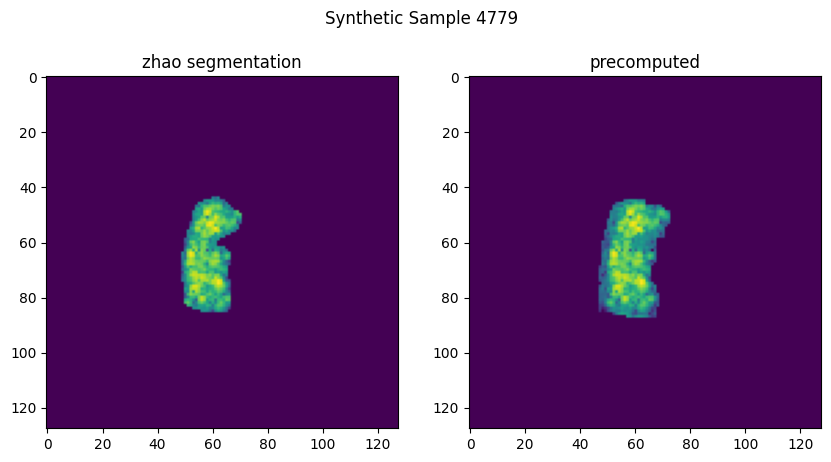

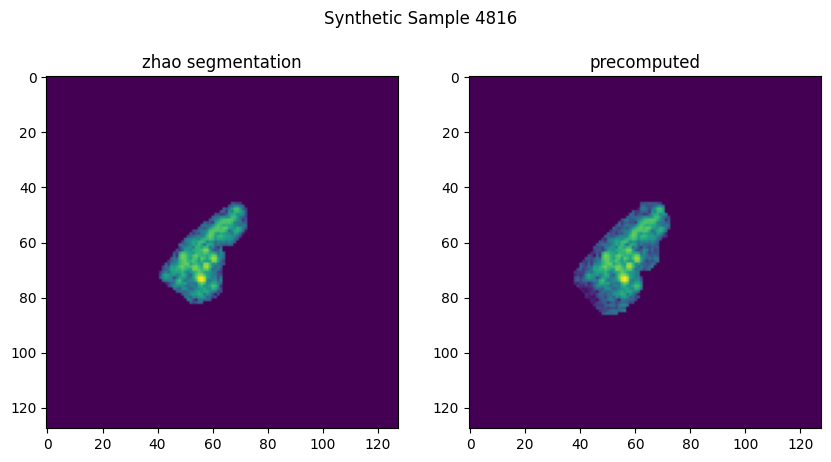

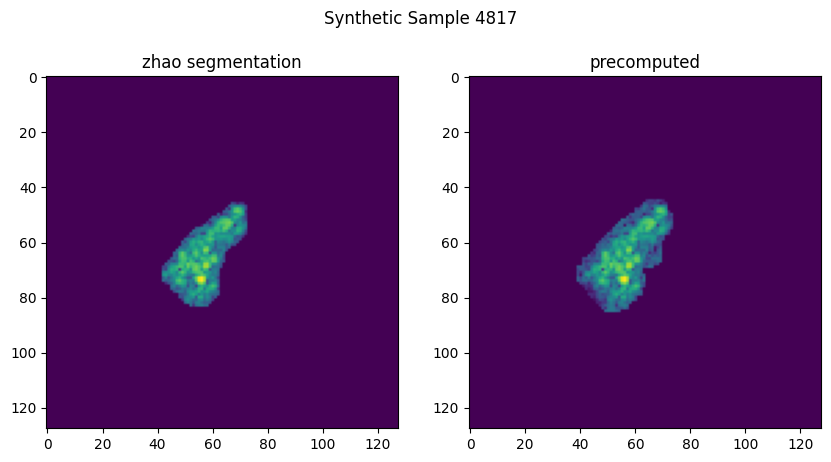

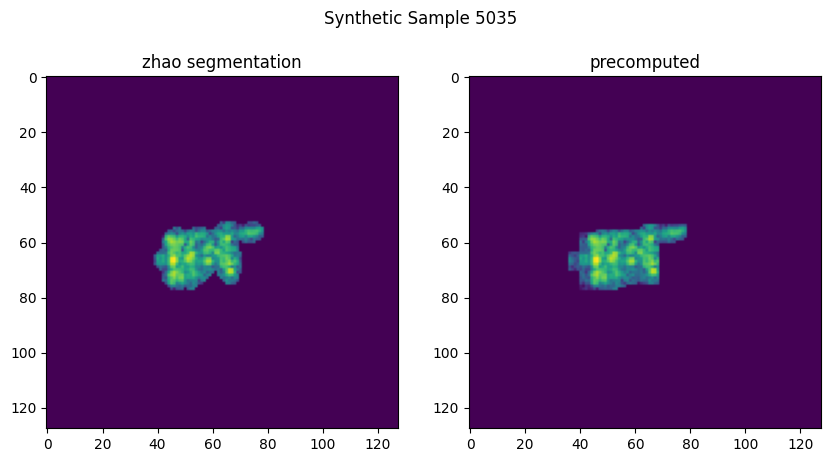

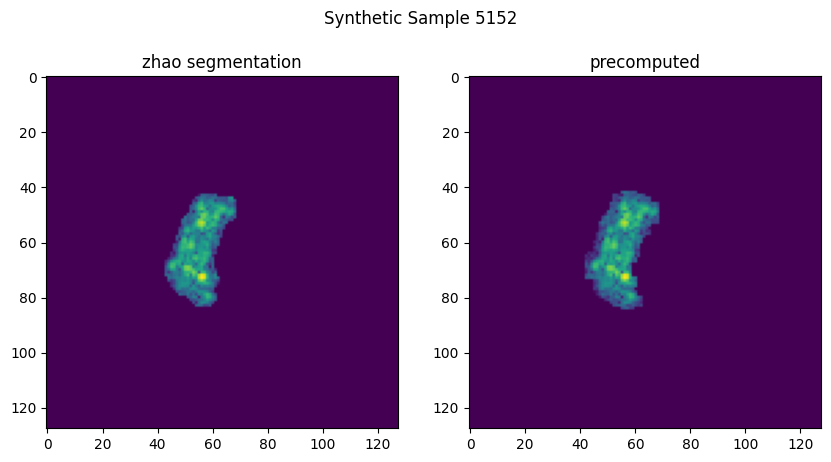

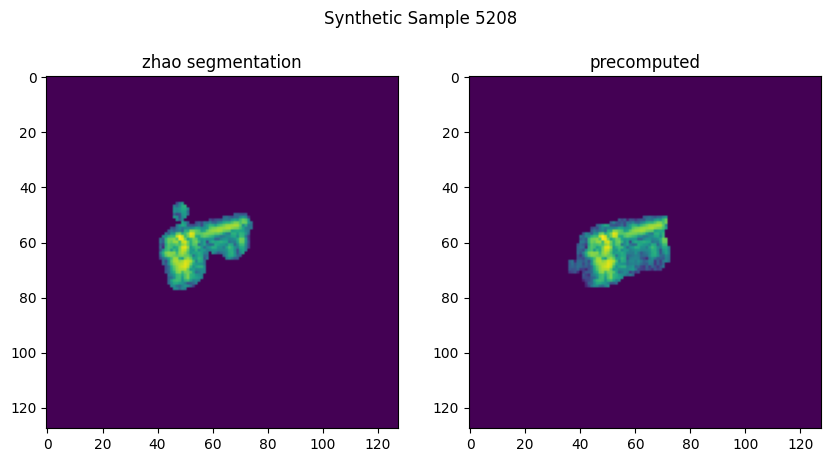

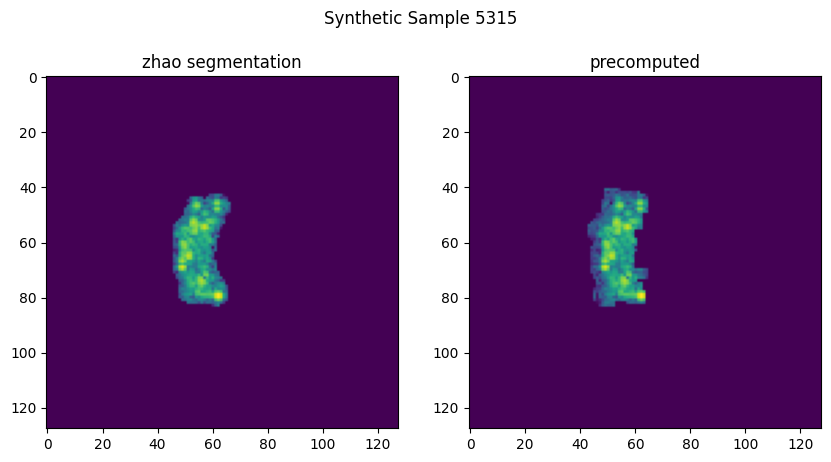

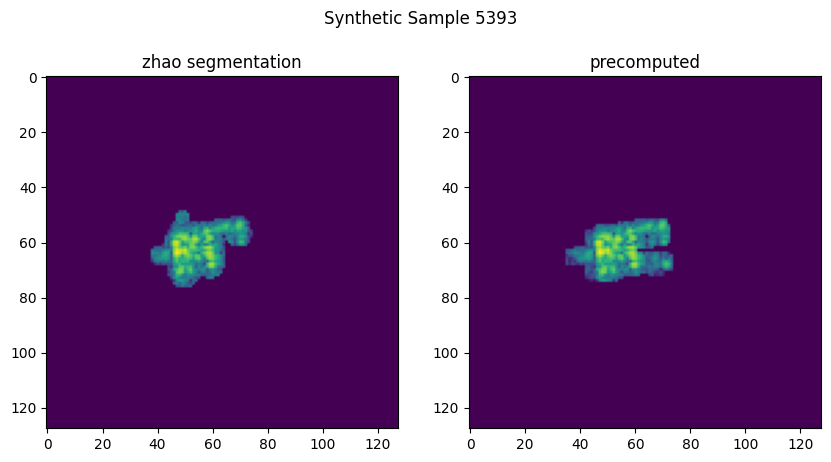

In [26]:
for i in [  11,  162,  185,  655,  851,  853, 1000, 1009, 1262, 1331, 1496,
       1569, 1911, 1918, 2207, 2317, 2560, 2626, 2753, 2758, 2801, 2859,
       2919, 2940, 2975, 3038, 3164, 3175, 3239, 3426, 3675, 3815, 3840,
       3890, 4002, 4049, 4238, 4257, 4352, 4502, 4668, 4699, 4779, 4816,
       4817, 5035, 5152, 5208, 5315, 5393]:

    fig = plt.figure(figsize = (10, 5))
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(zhao_target_synth_ds[i][0][0].numpy())
    ax0.set_title("zhao segmentation")

    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(precomputed_target_synth_ds[i][0][0].numpy())
    ax1.set_title("precomputed")

    fig.suptitle(f"Synthetic Sample {i}")
    plt.show()

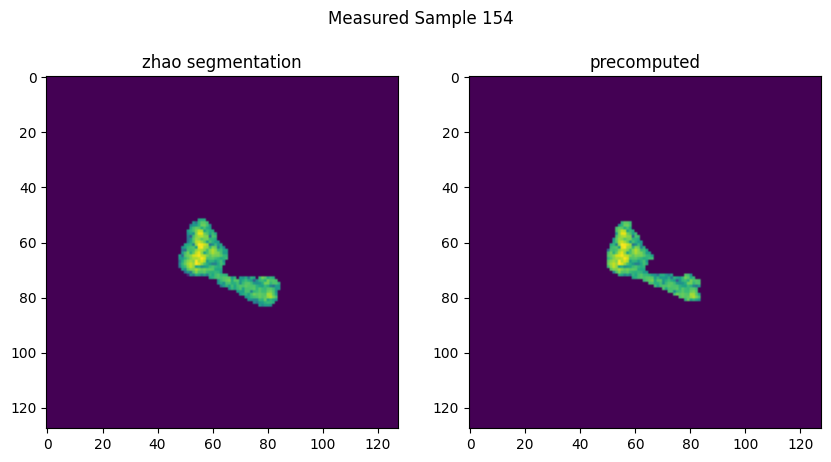

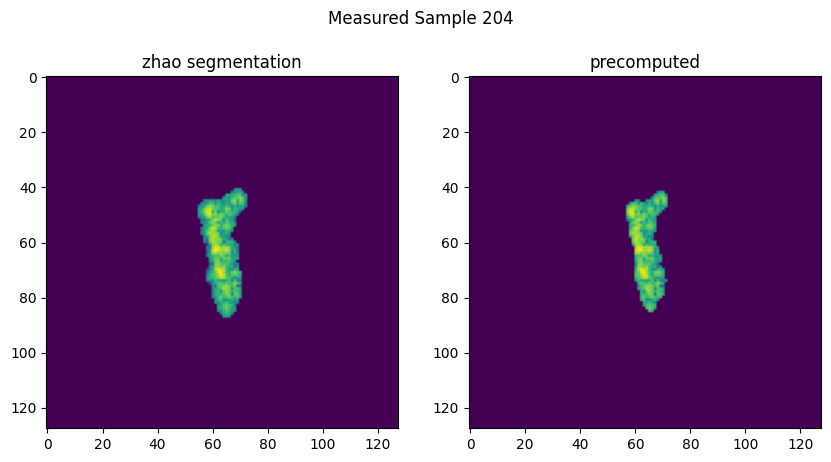

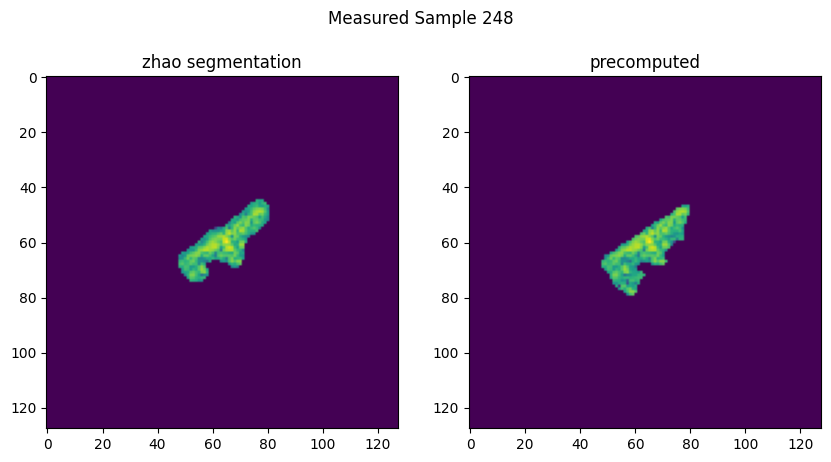

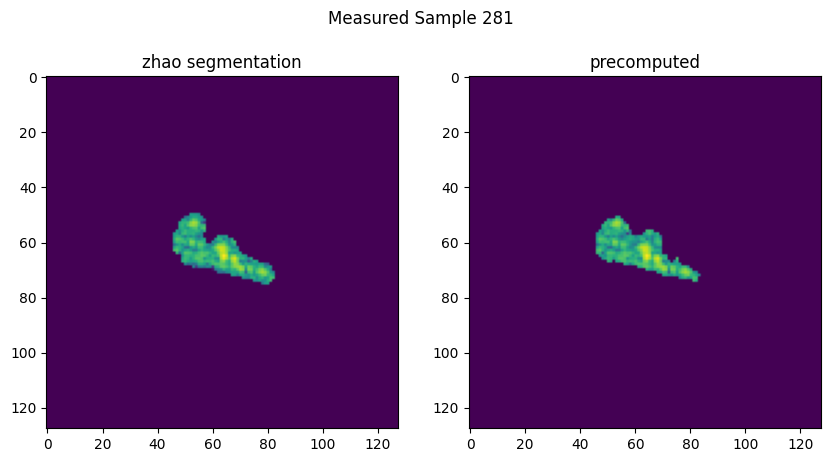

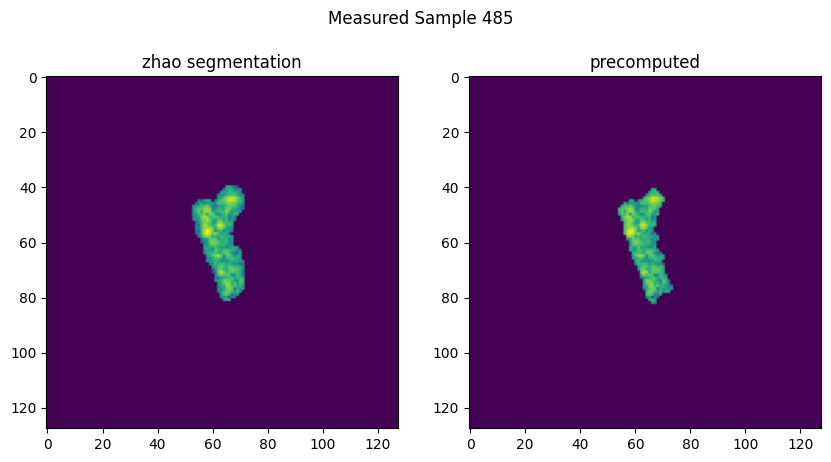

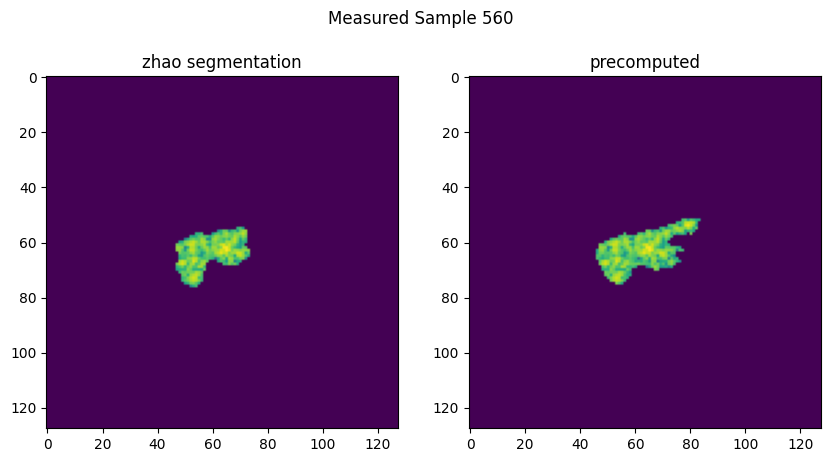

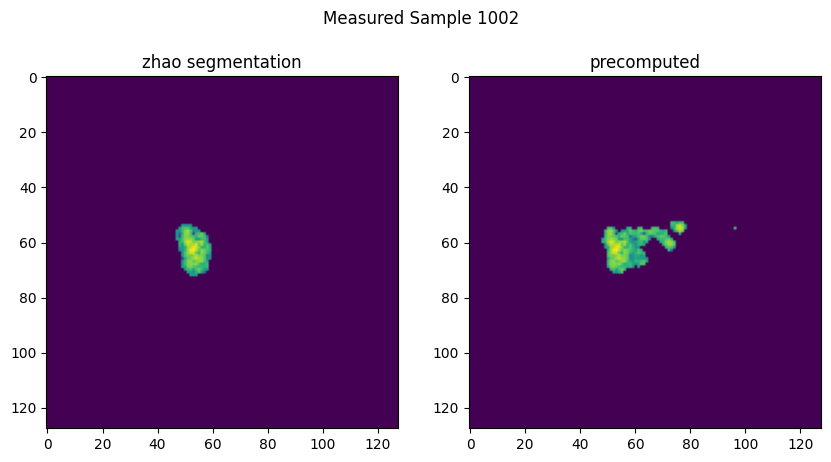

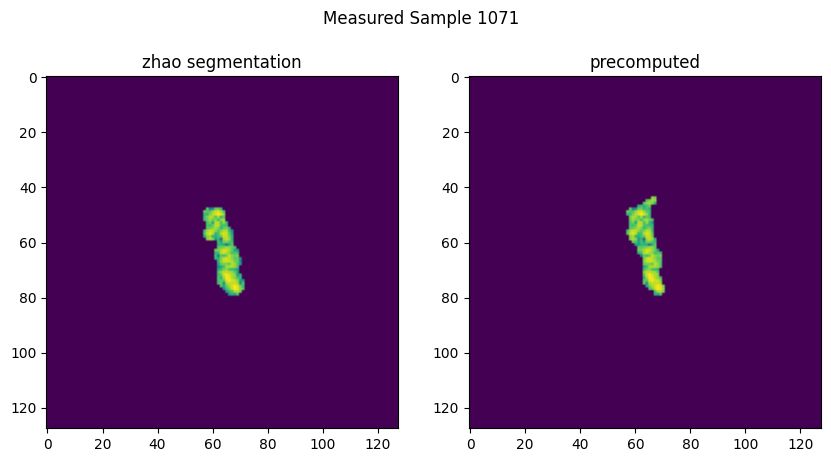

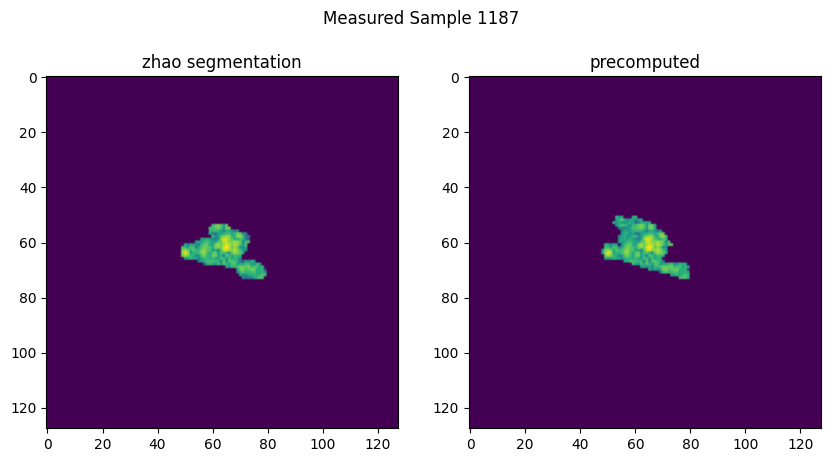

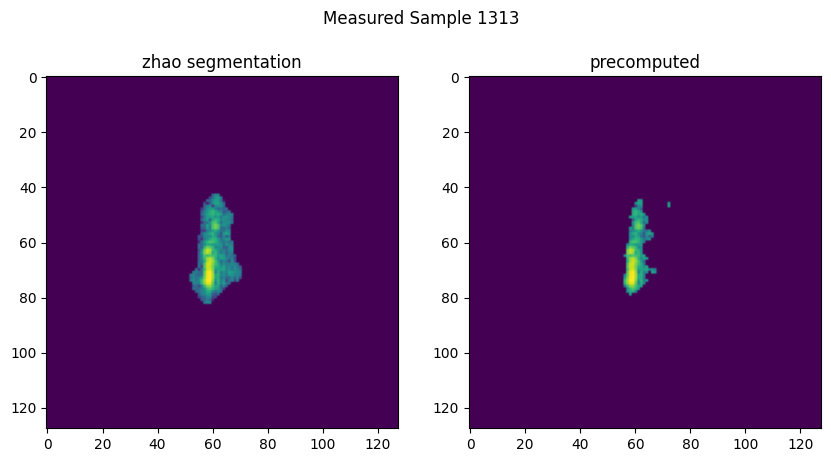

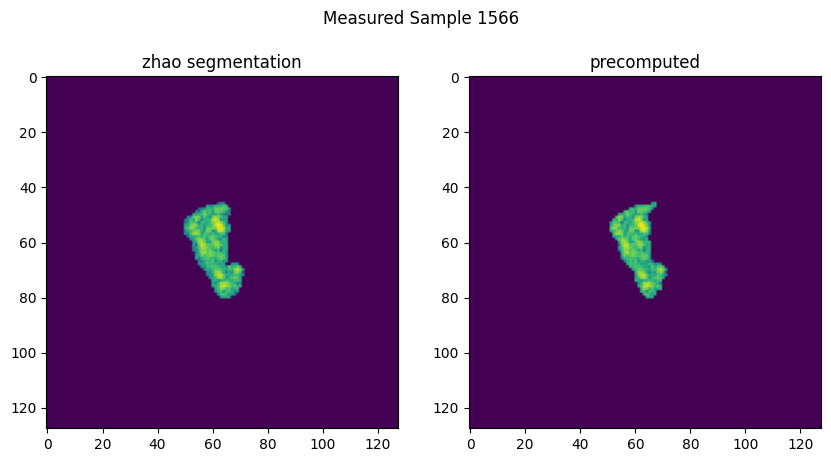

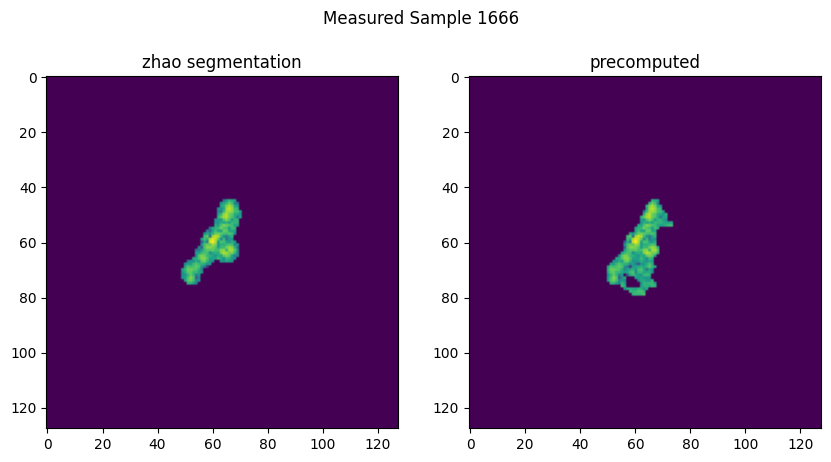

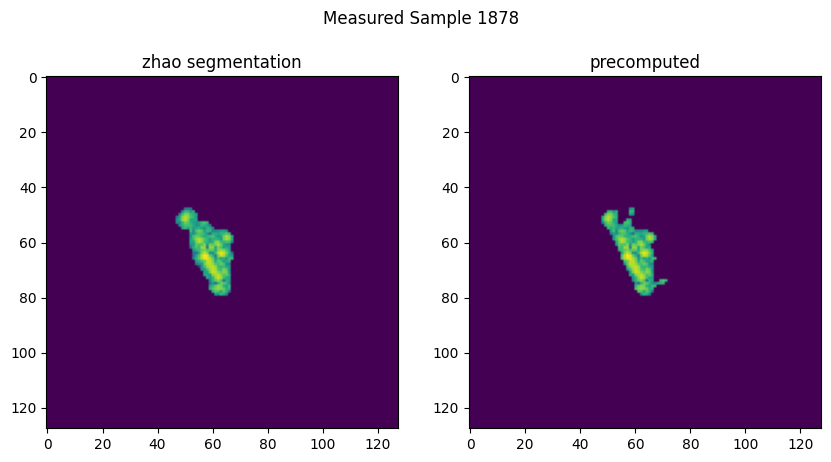

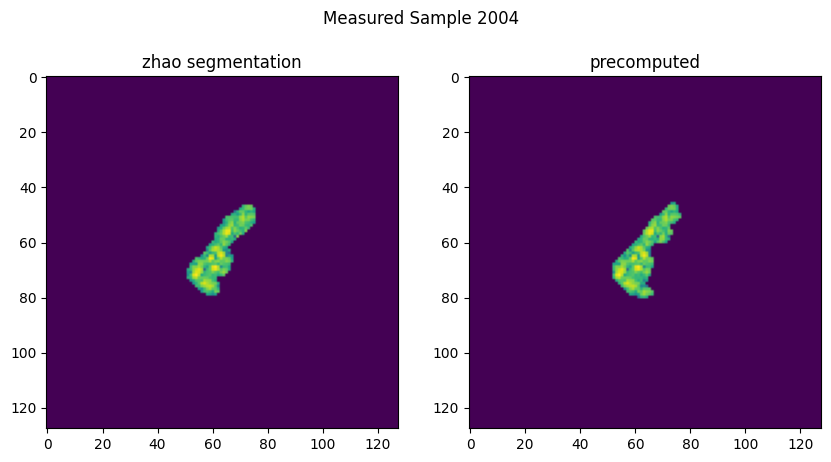

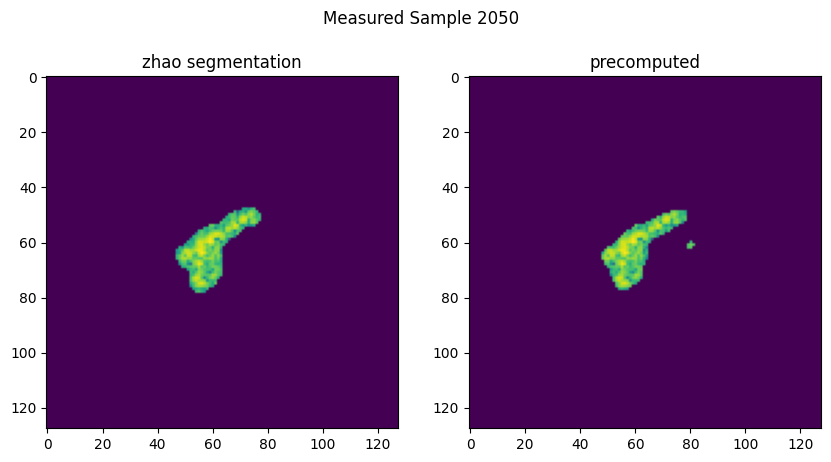

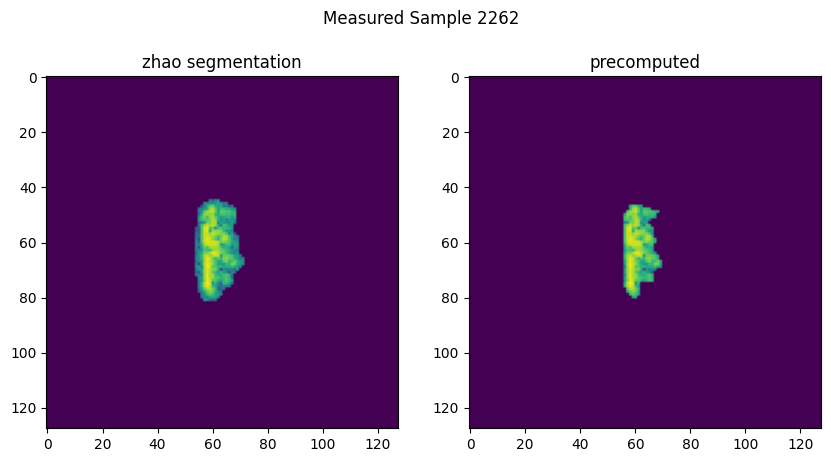

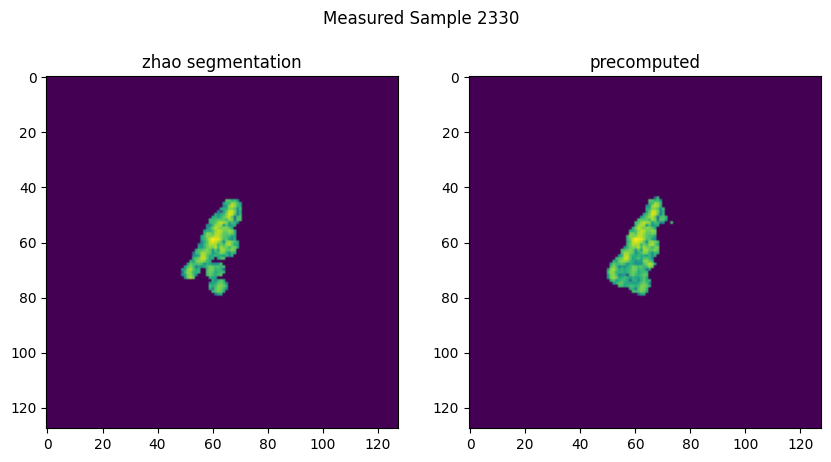

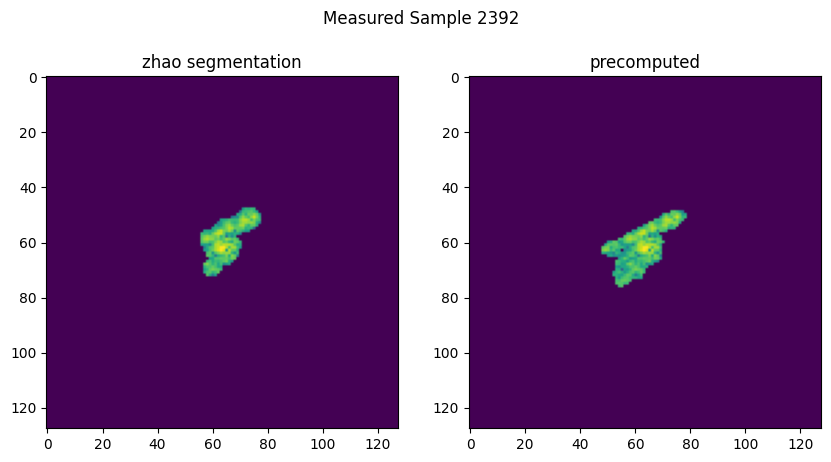

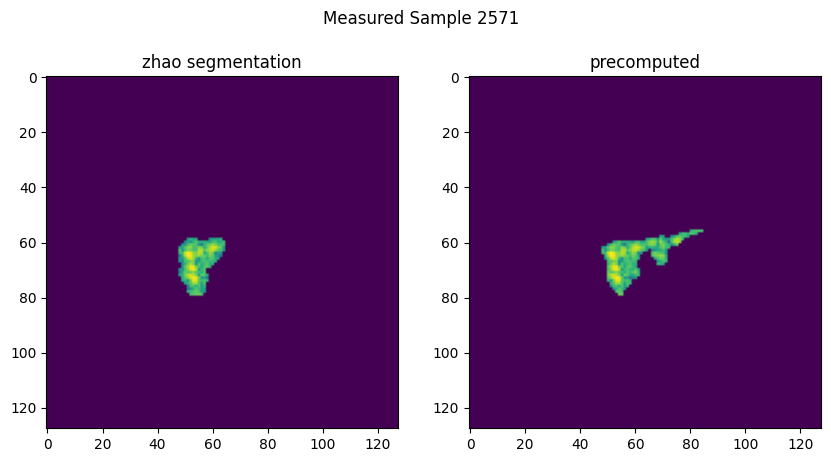

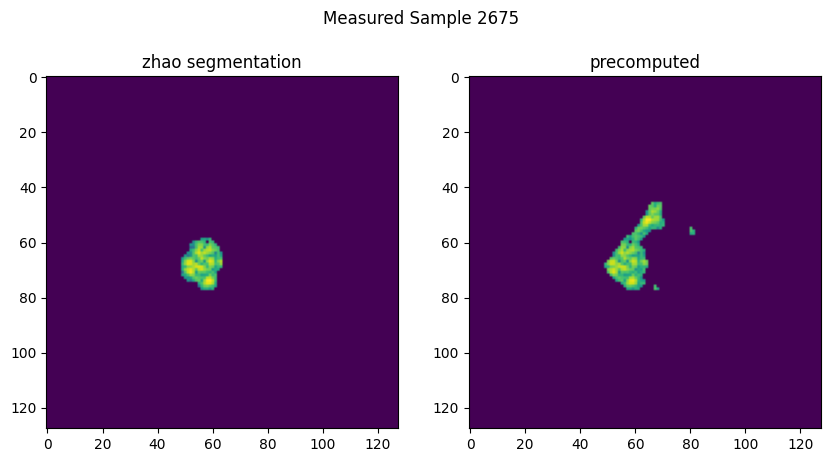

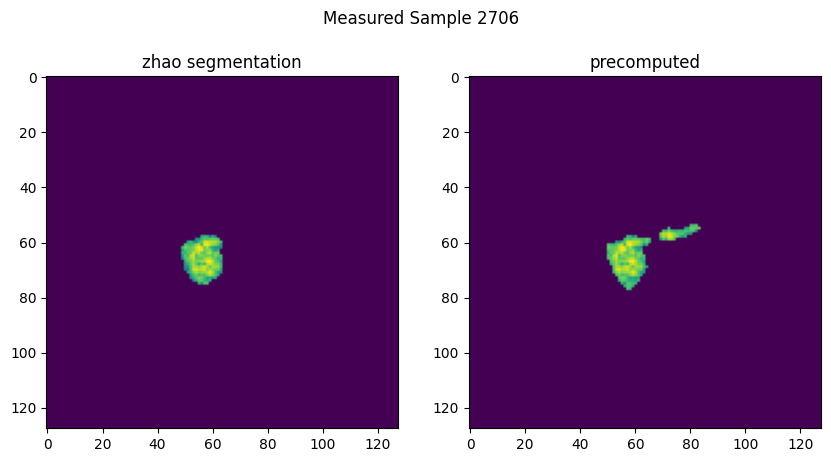

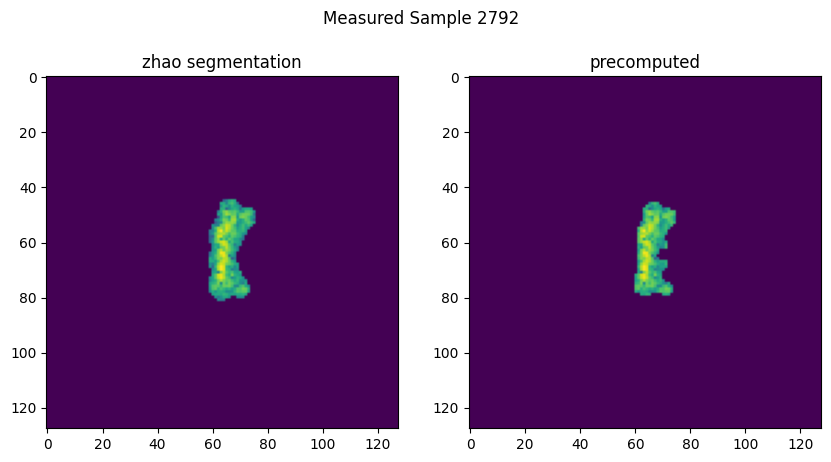

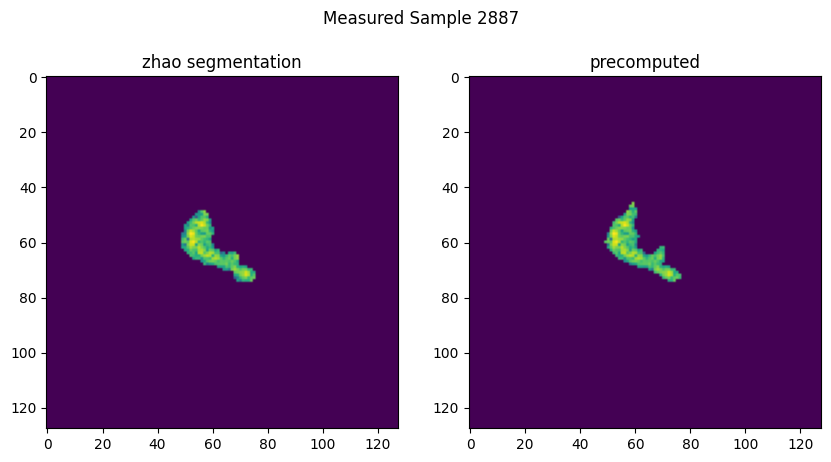

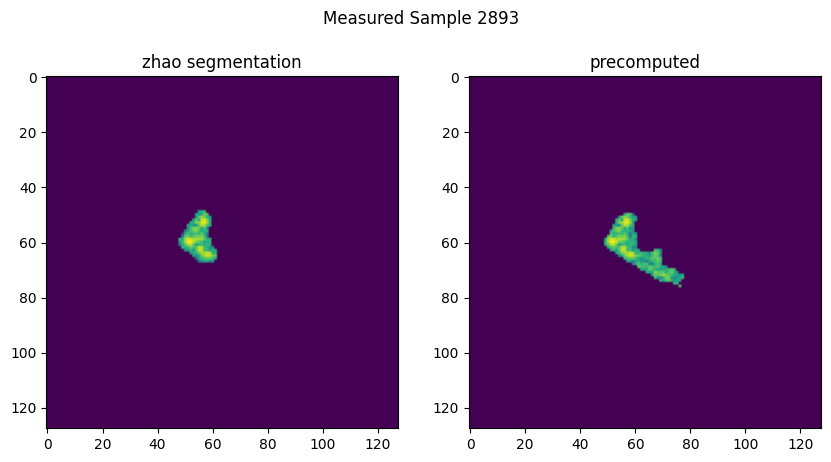

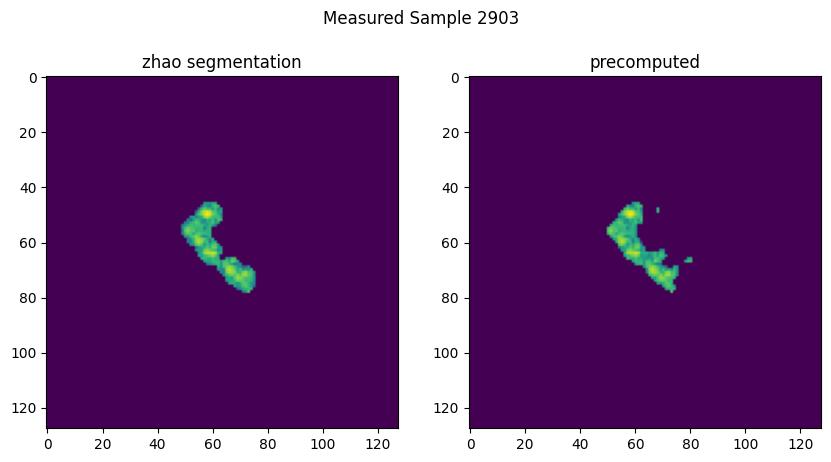

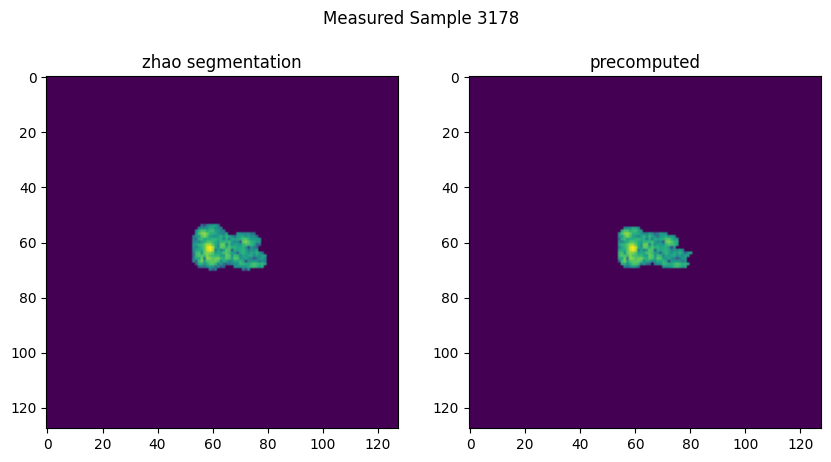

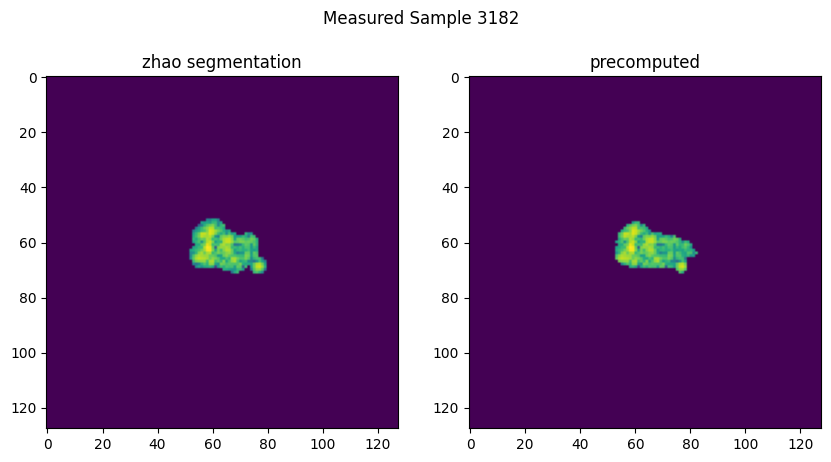

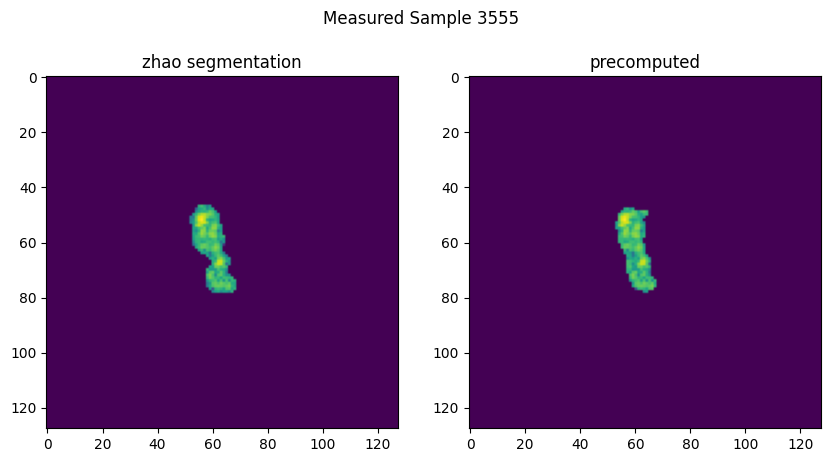

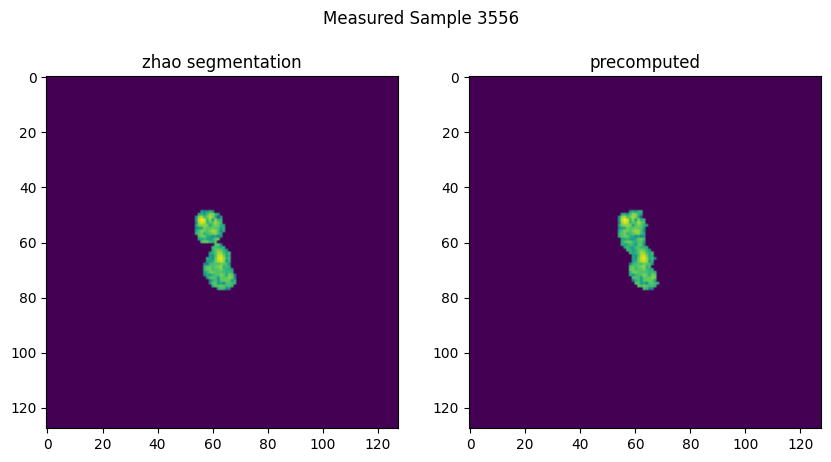

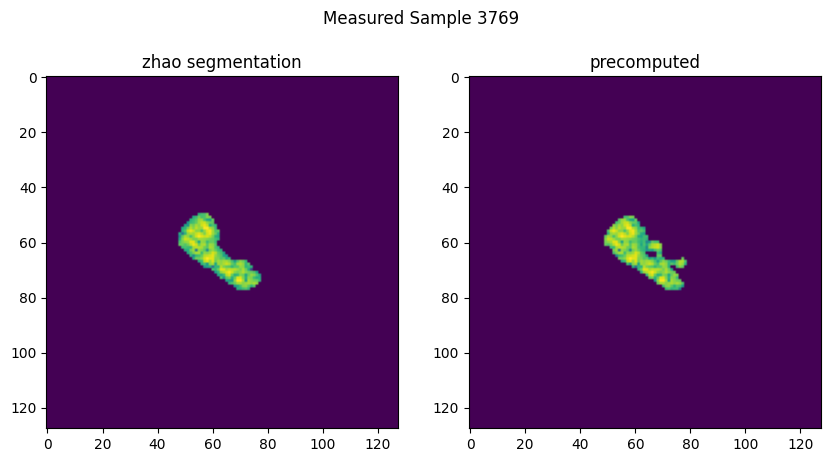

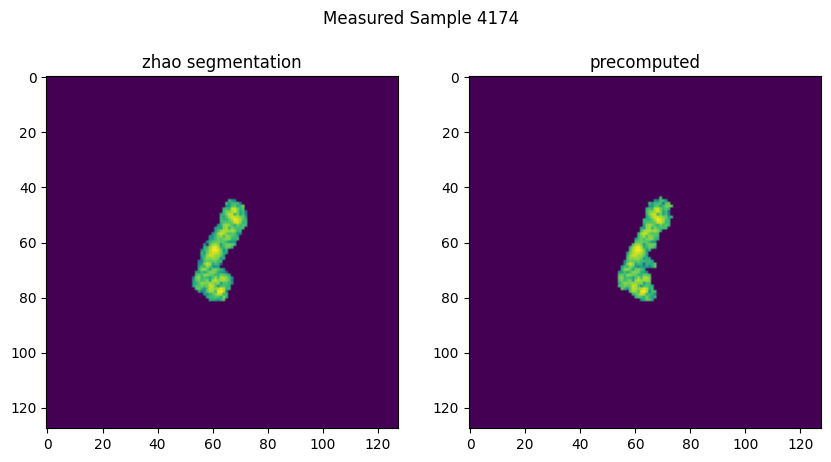

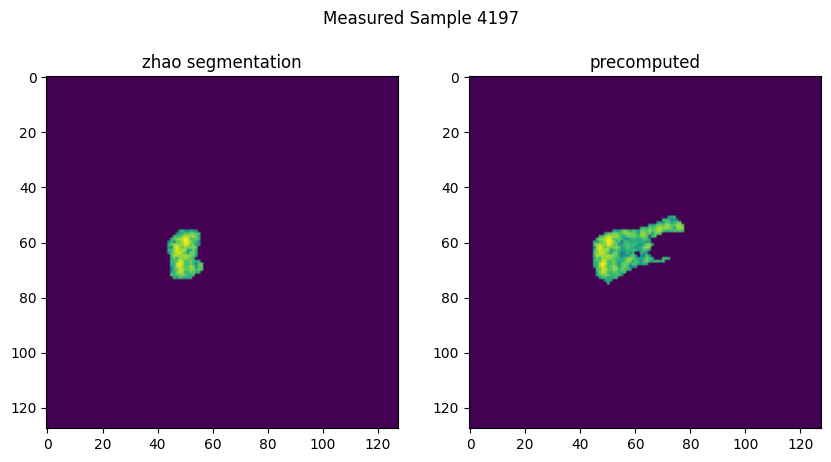

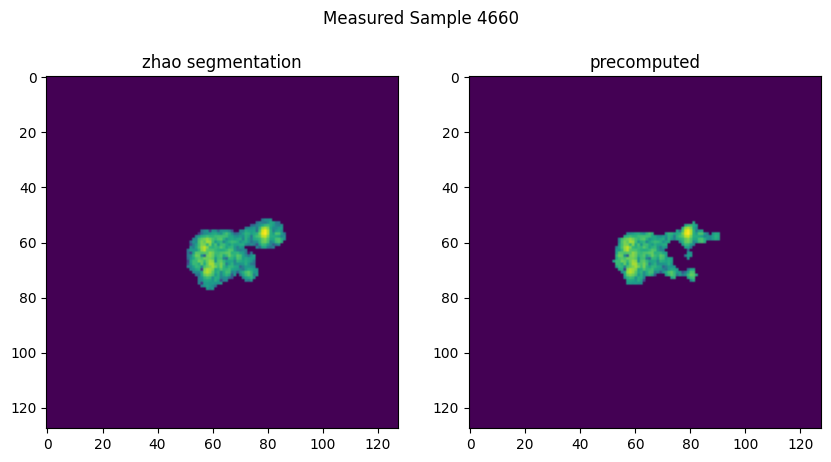

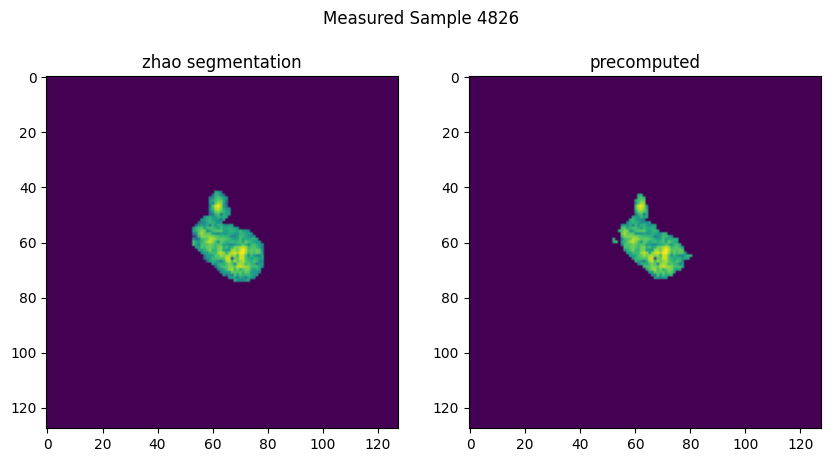

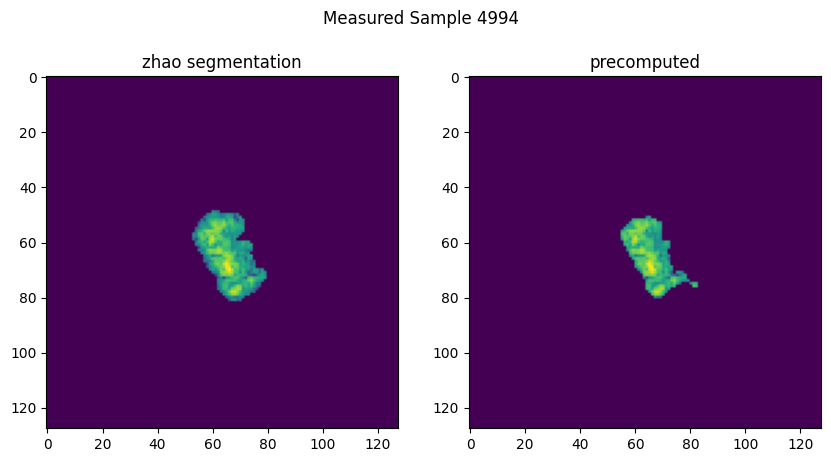

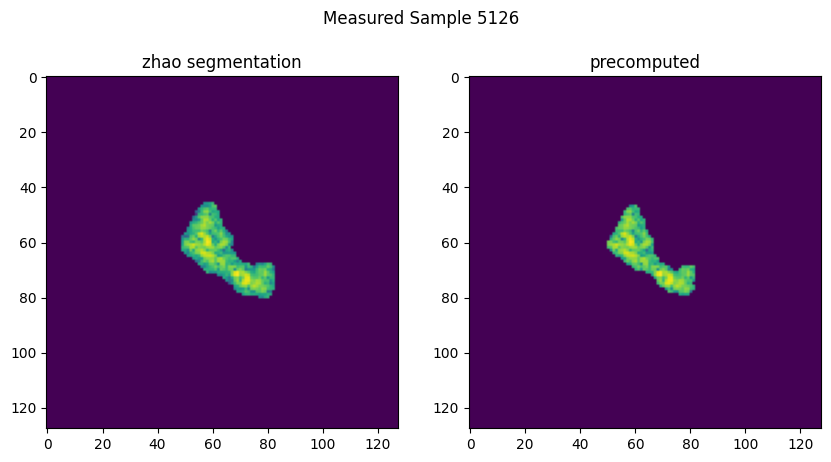

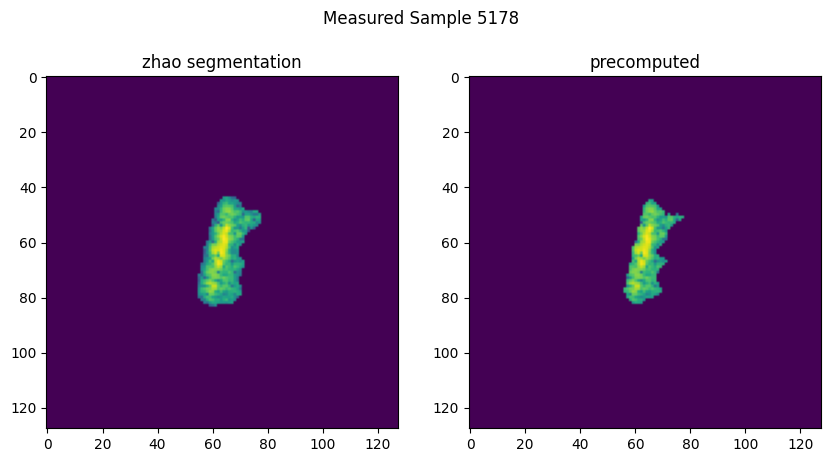

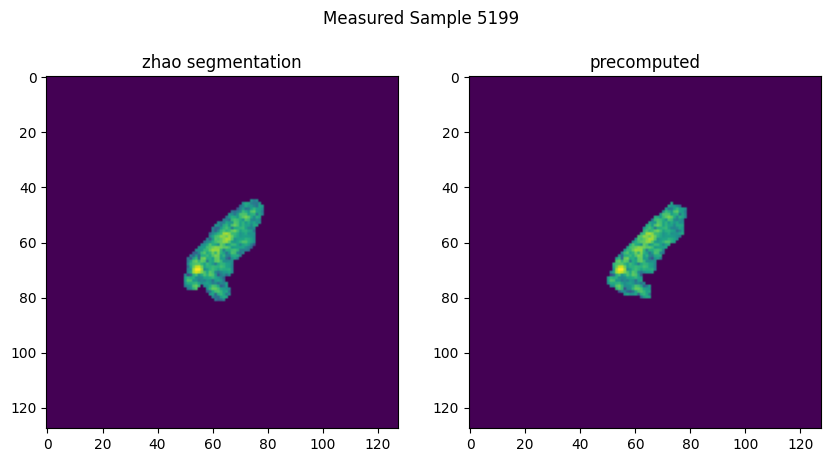

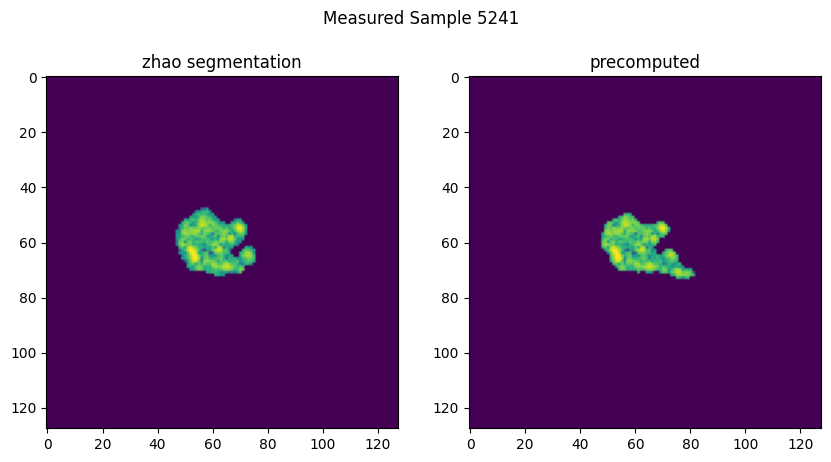

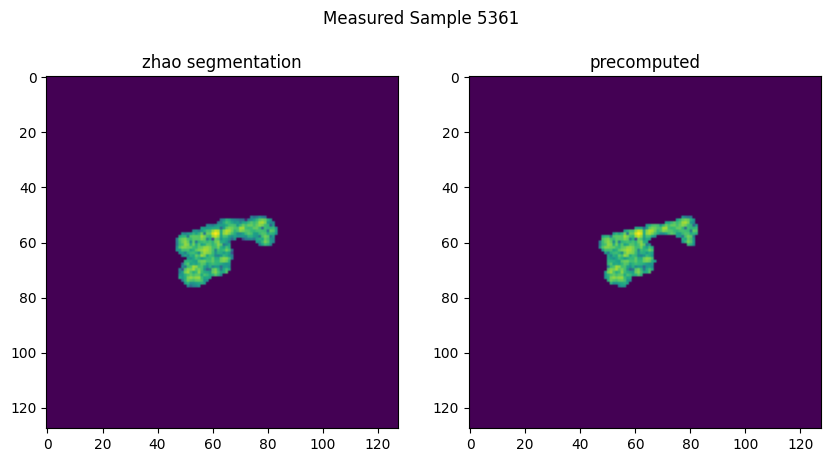

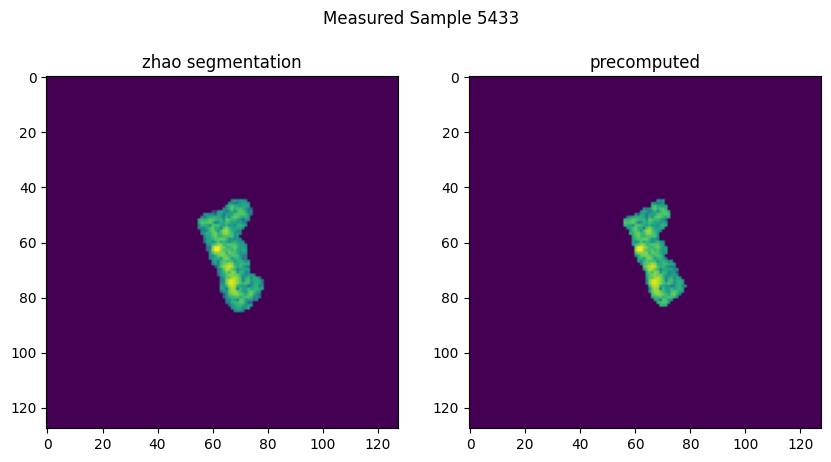

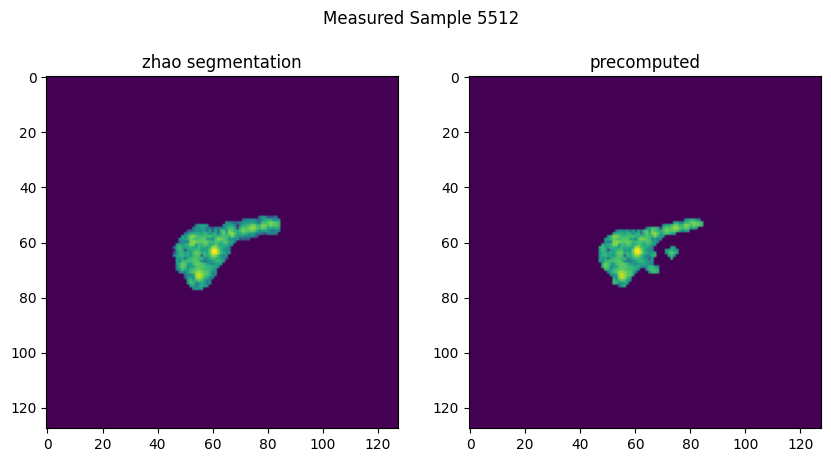

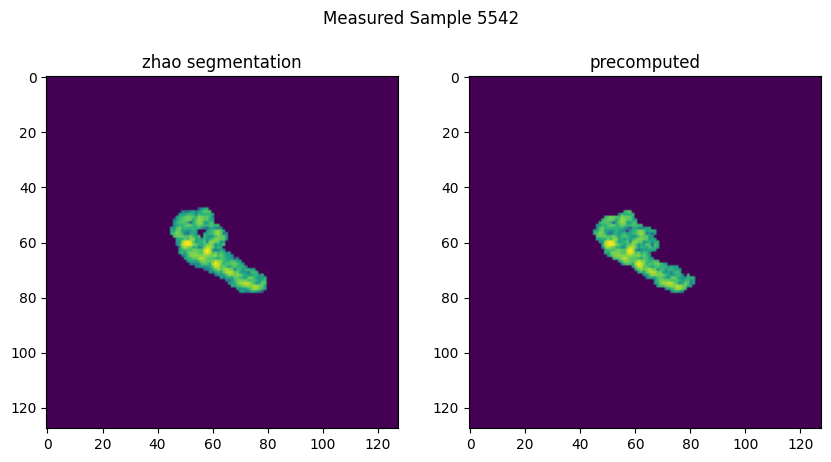

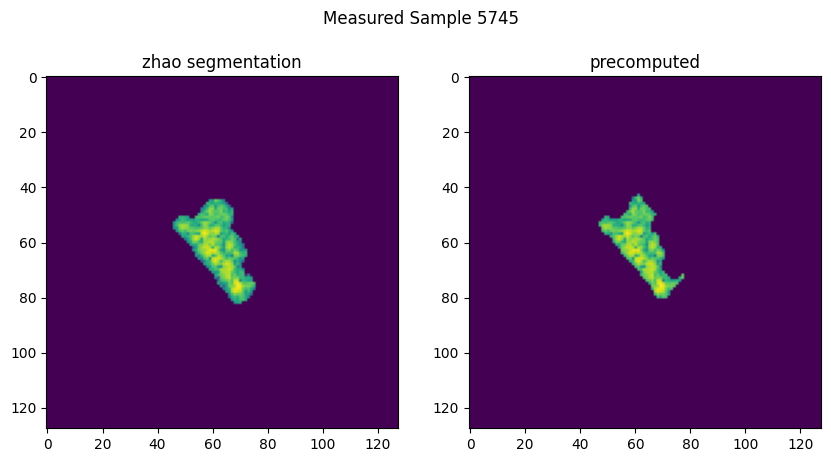

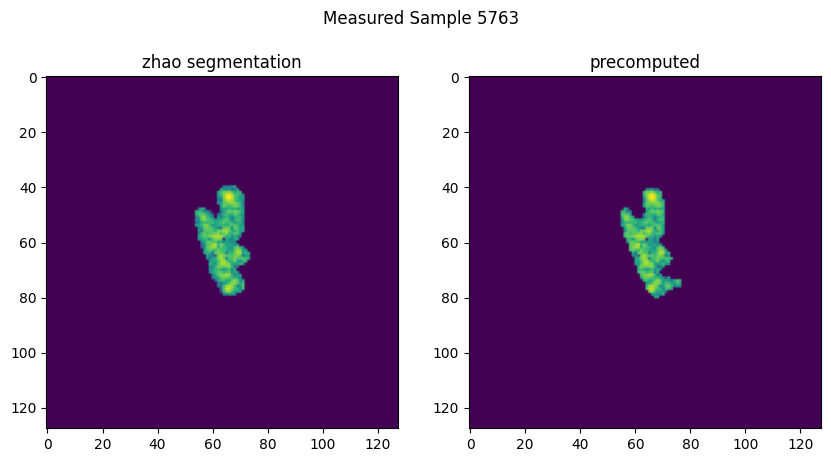

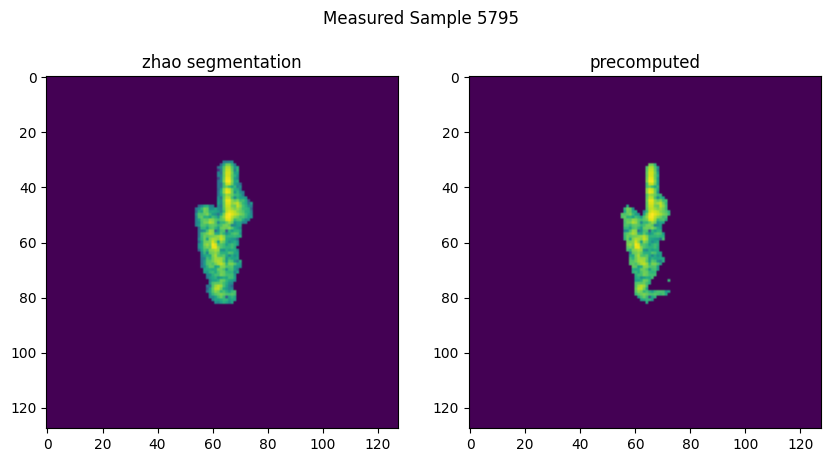

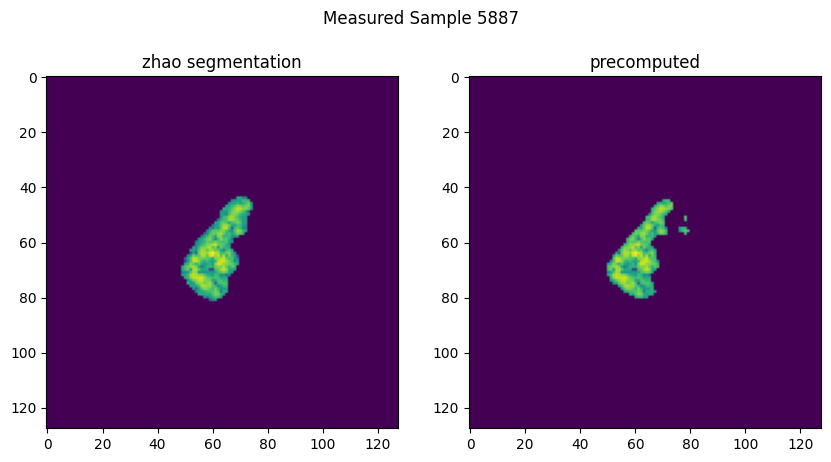

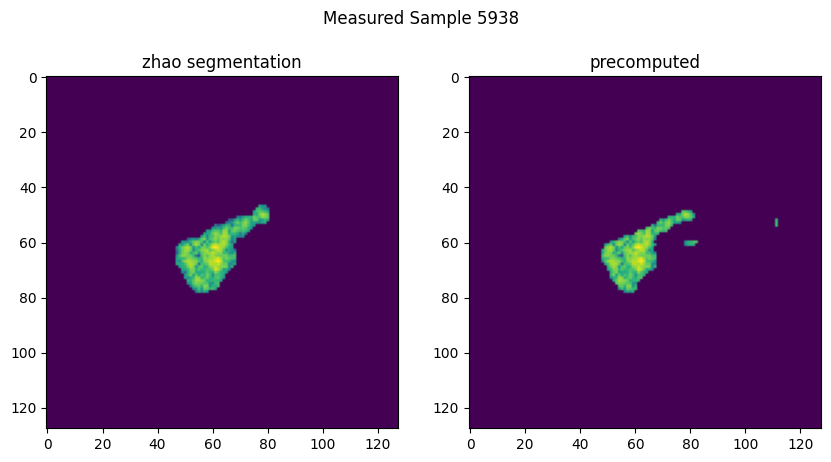

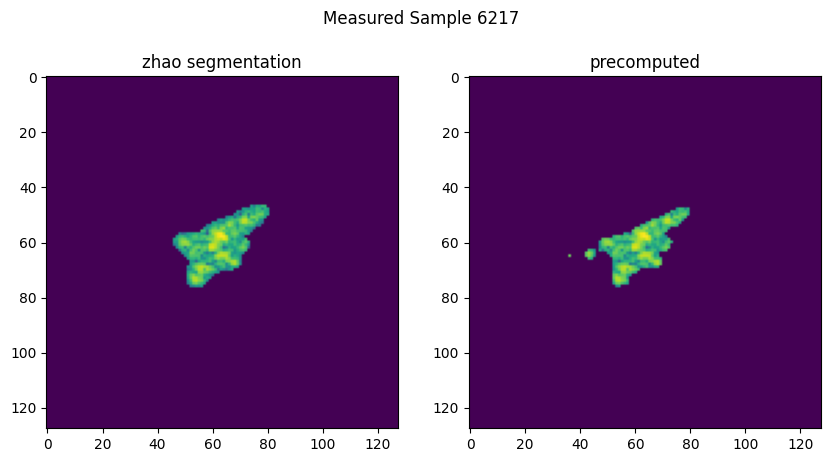

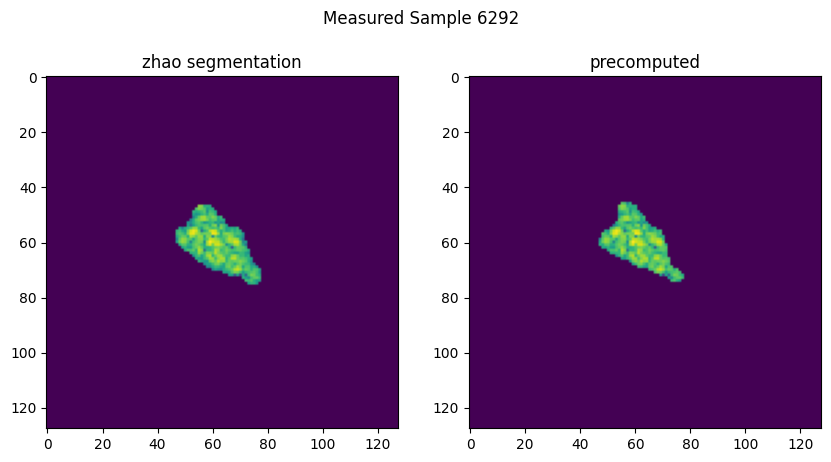

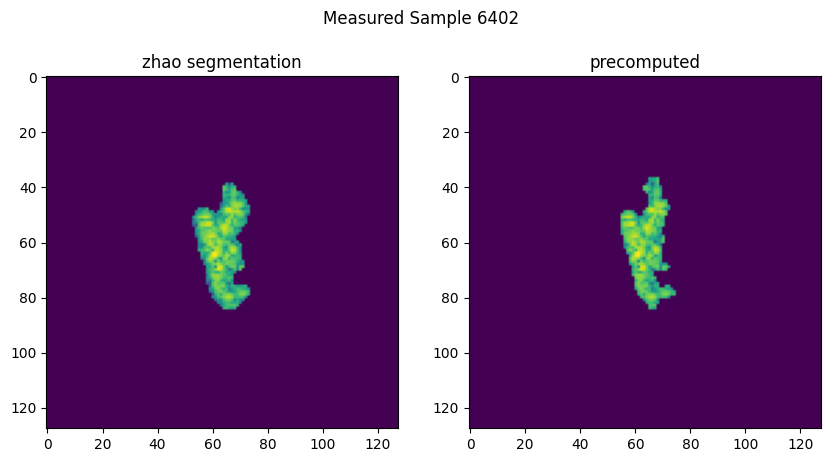

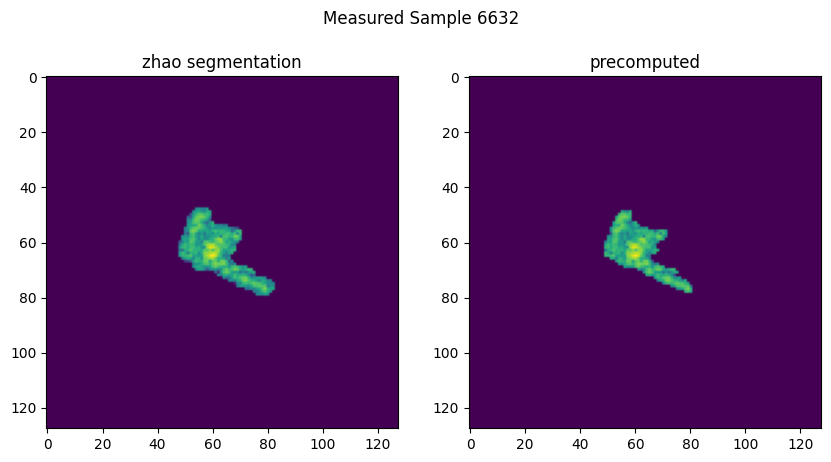

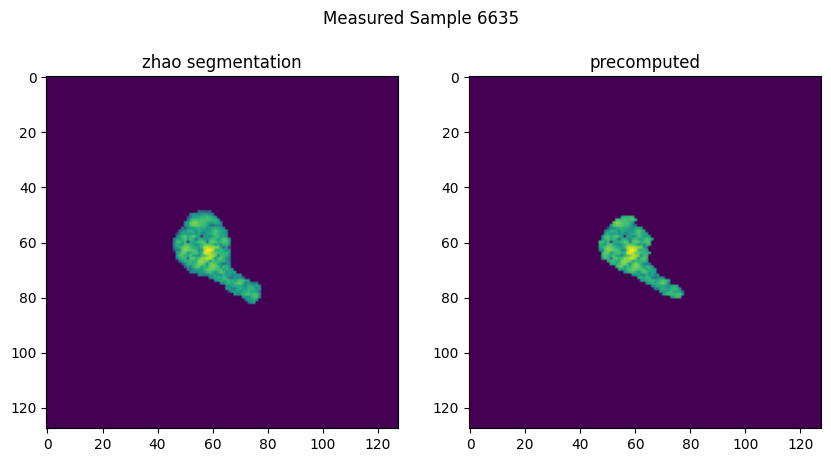

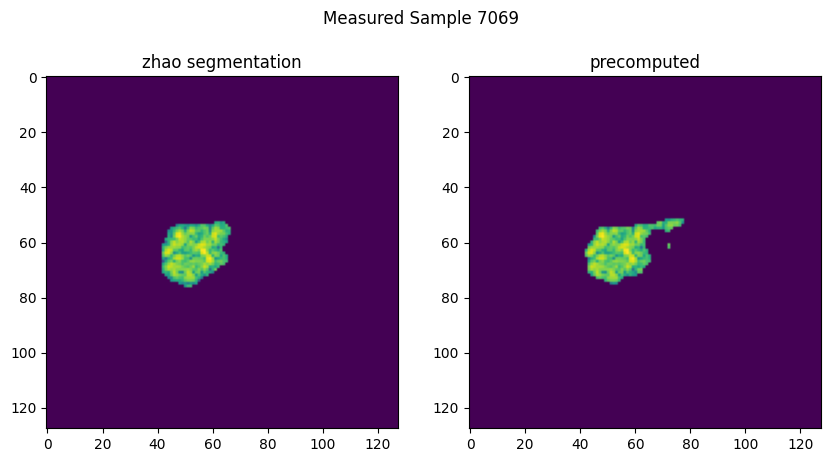

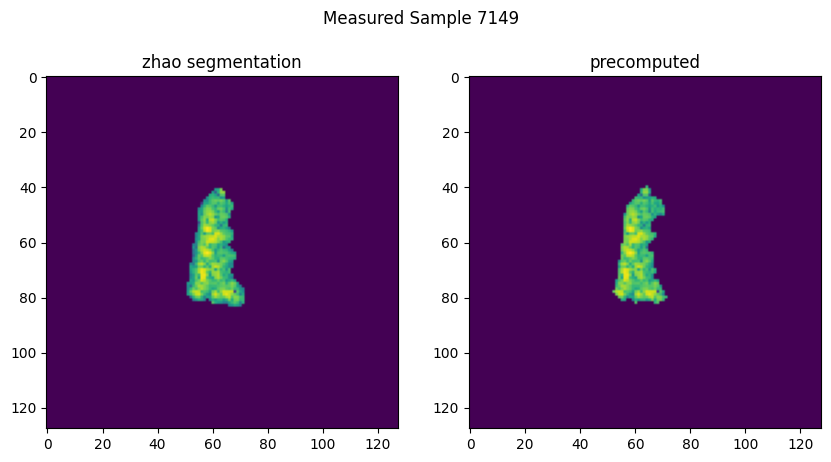

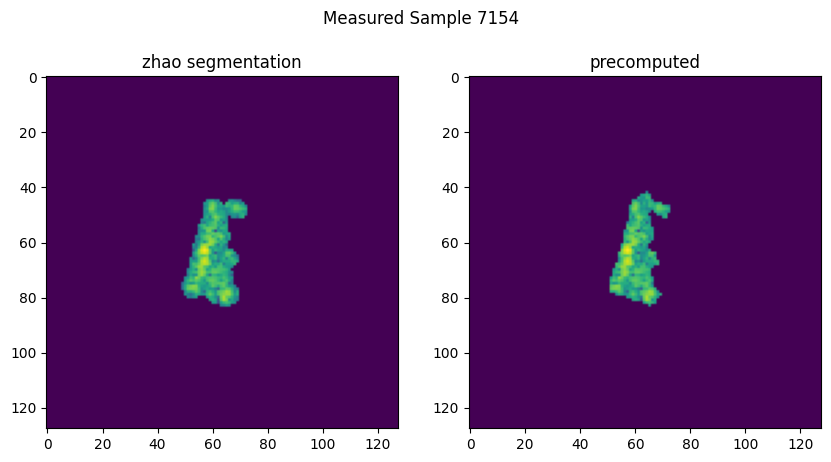

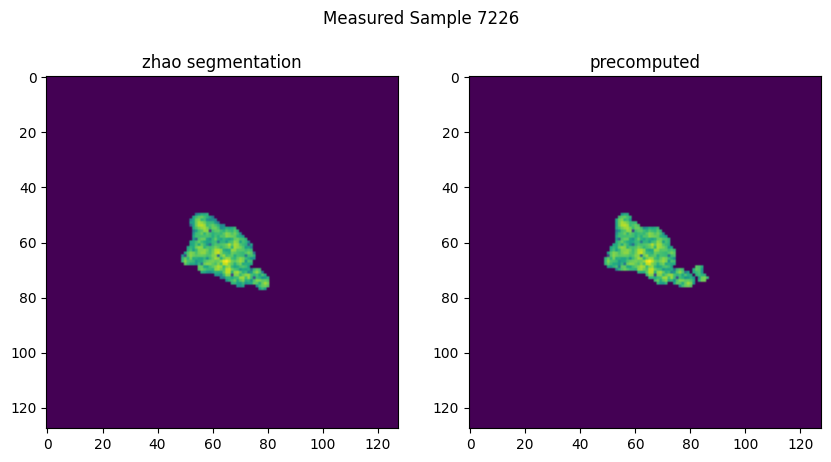

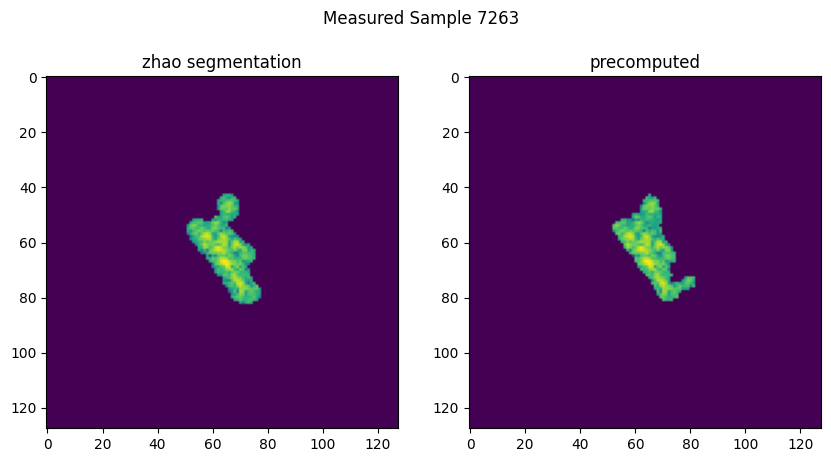

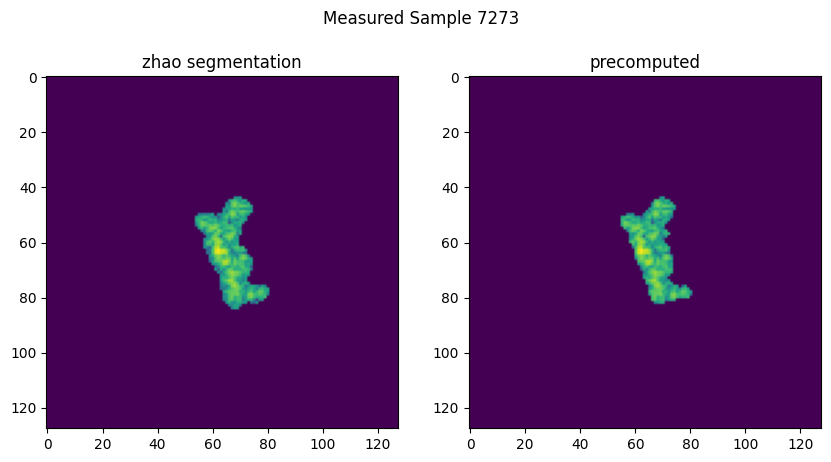

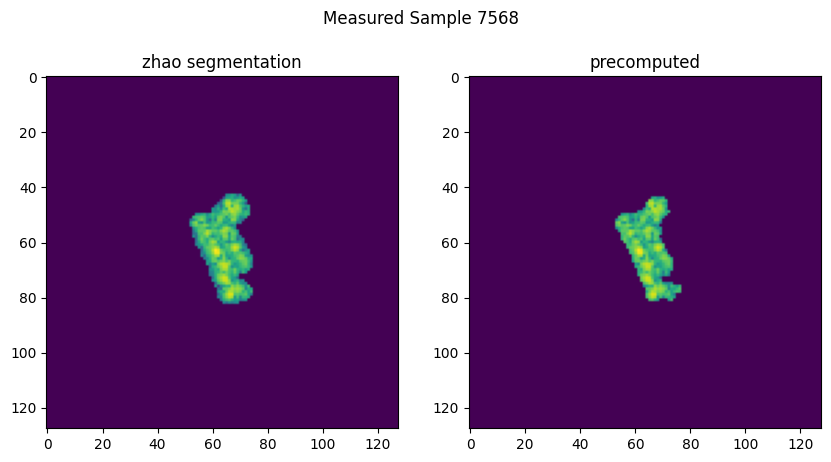

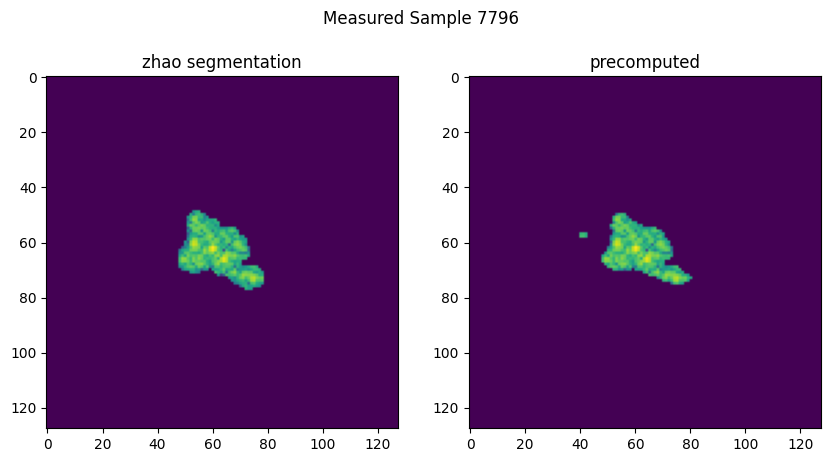

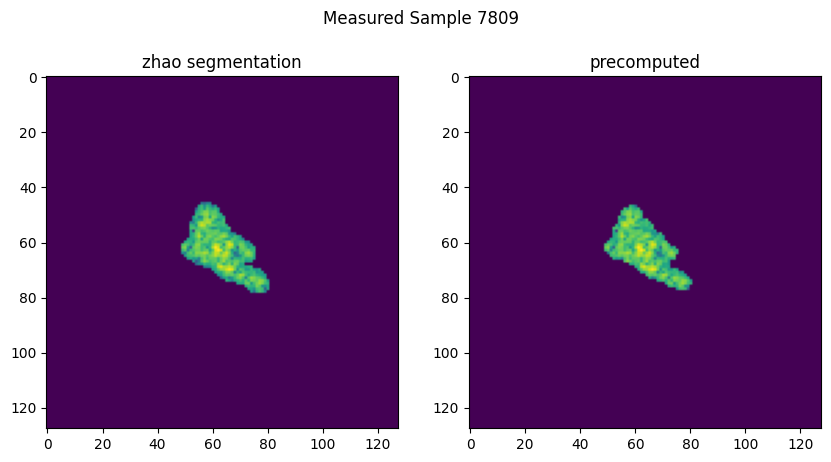

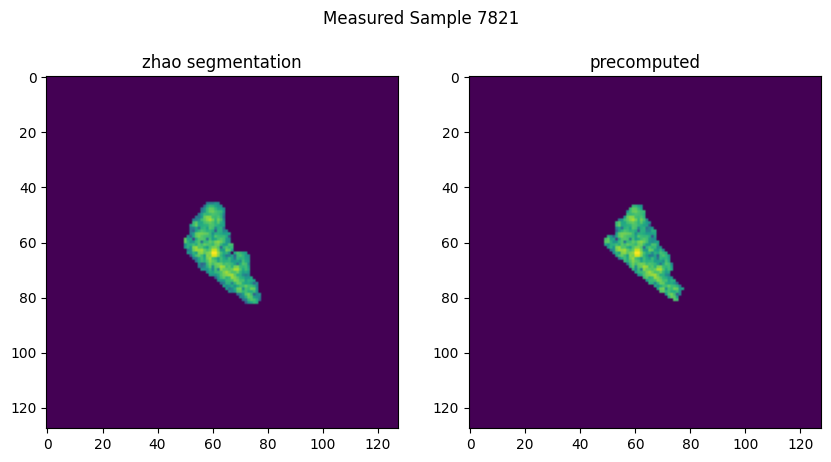

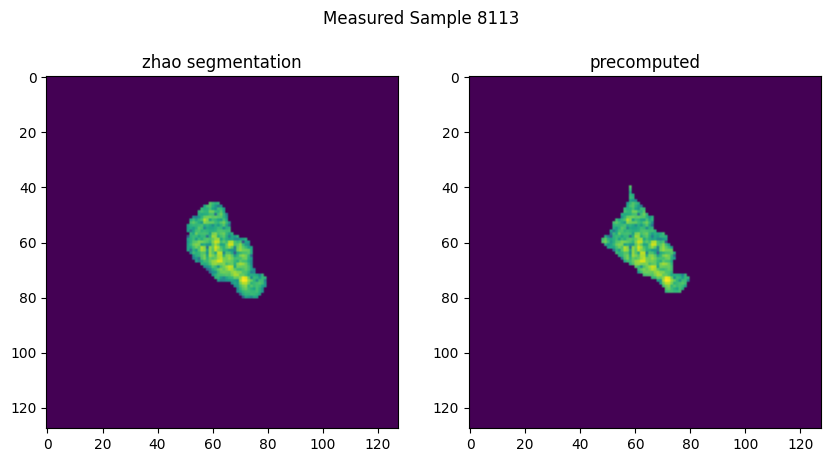

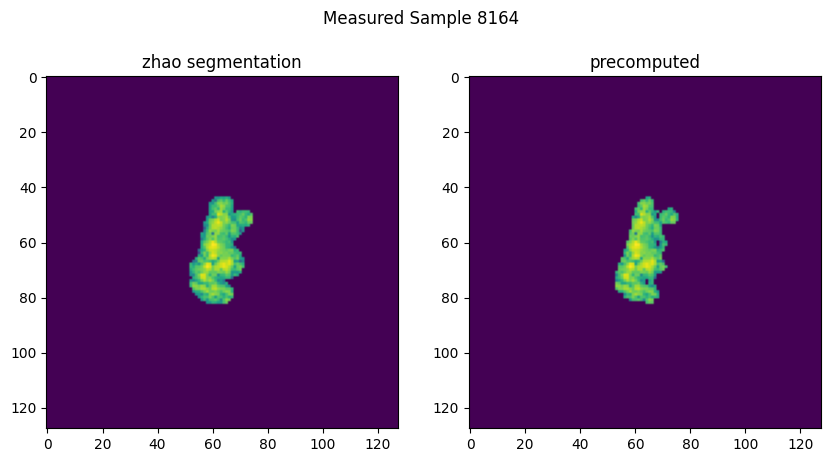

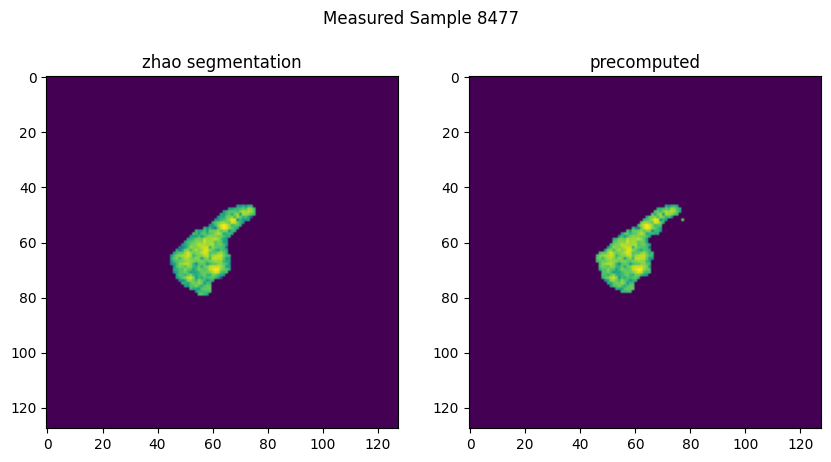

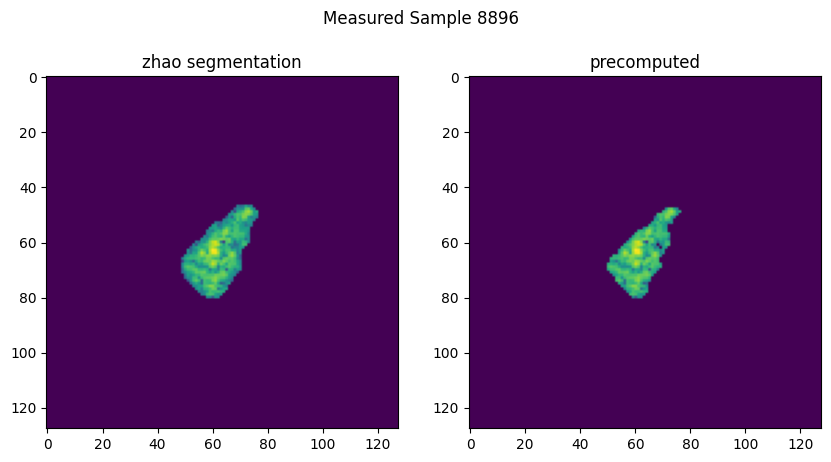

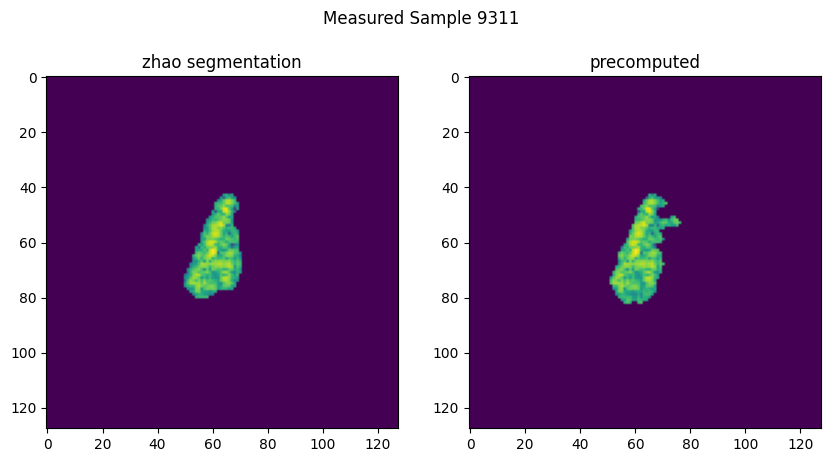

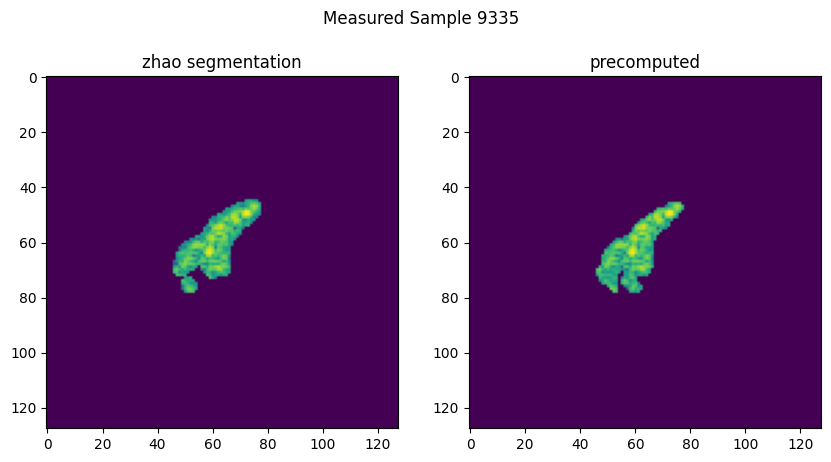

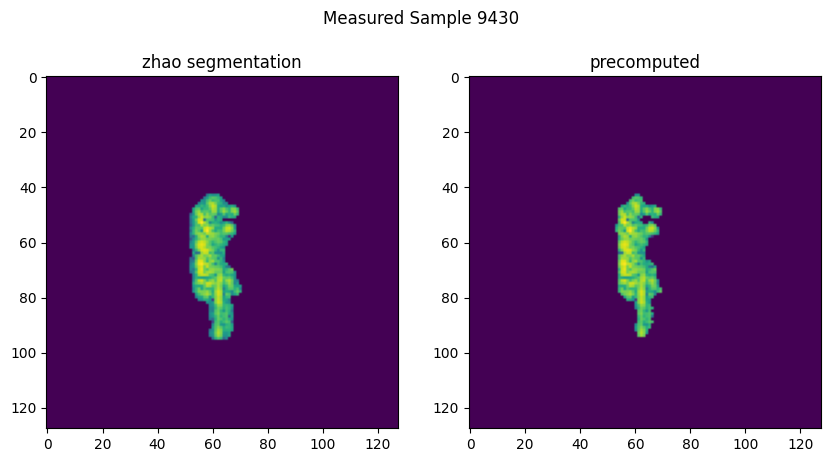

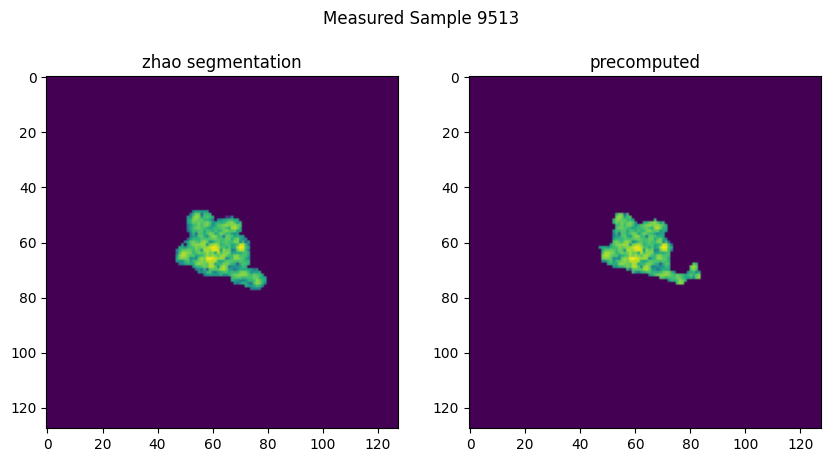

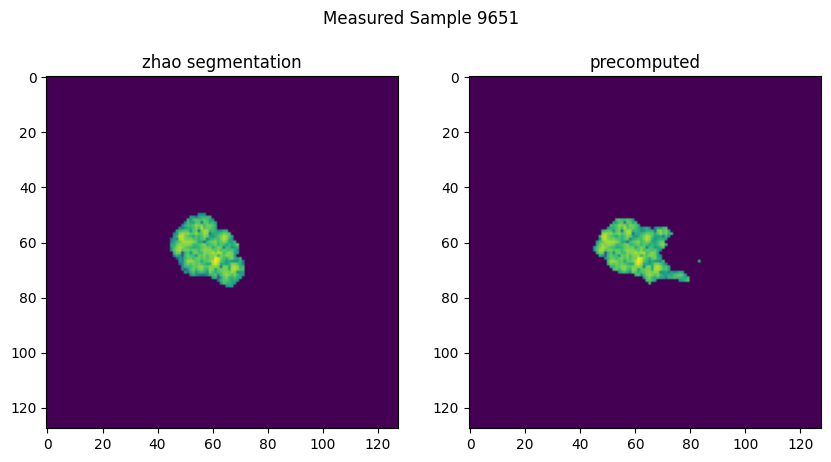

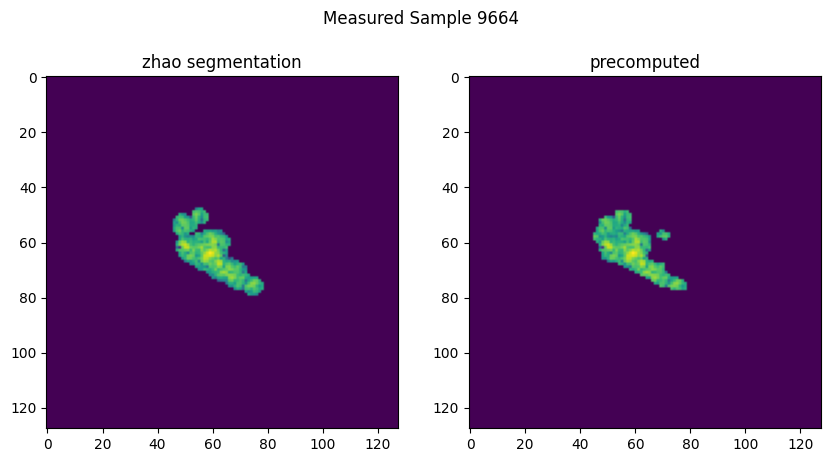

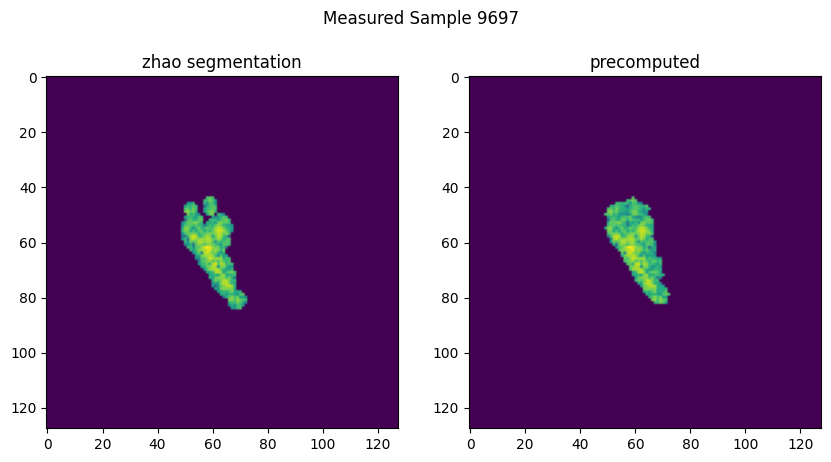

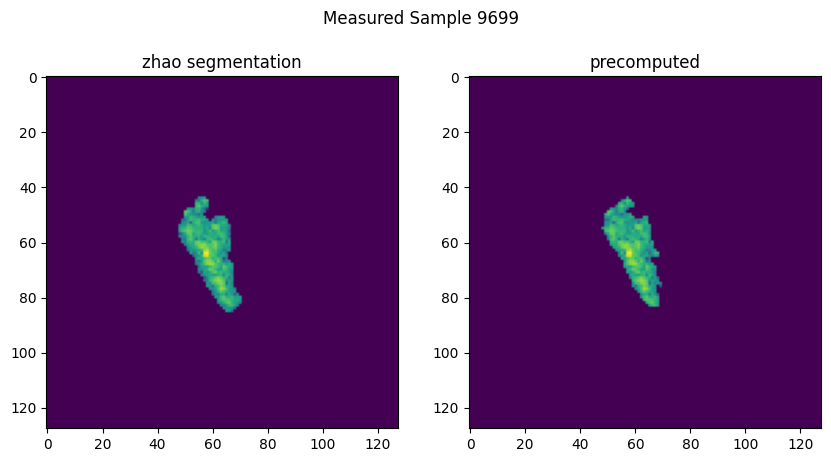

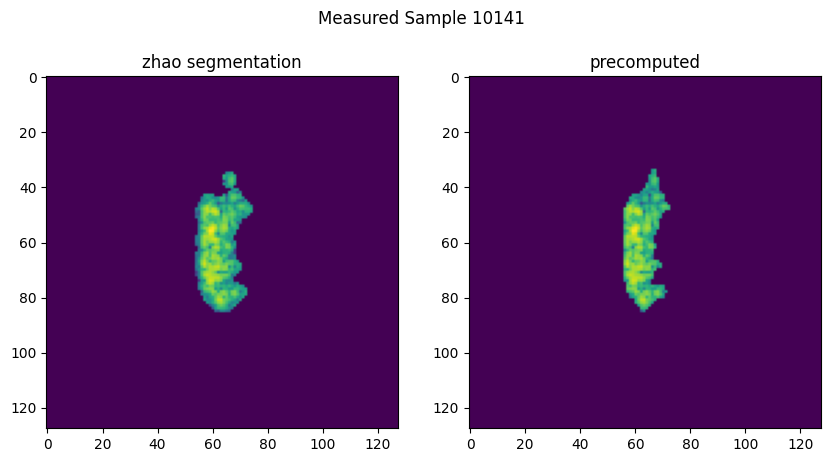

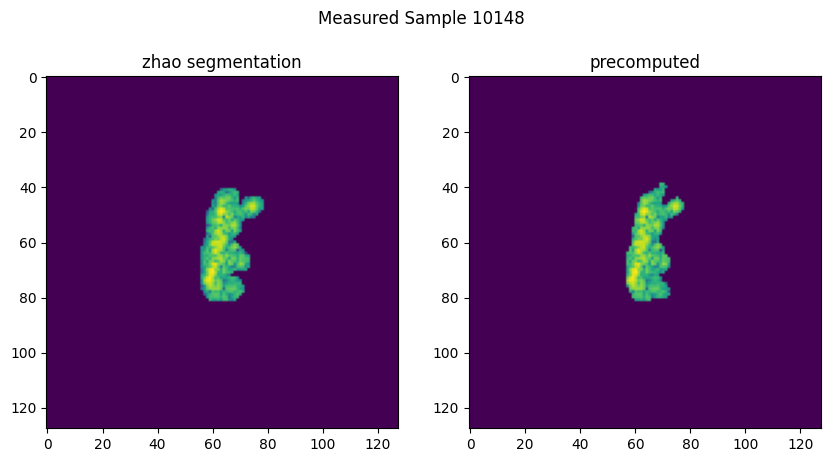

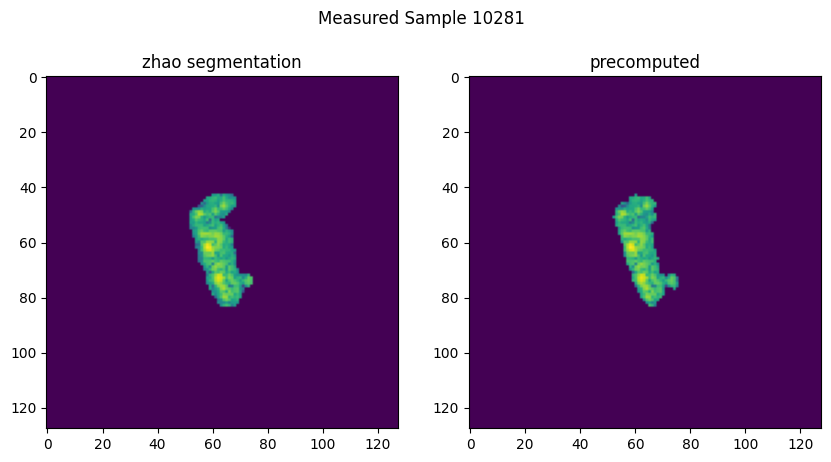

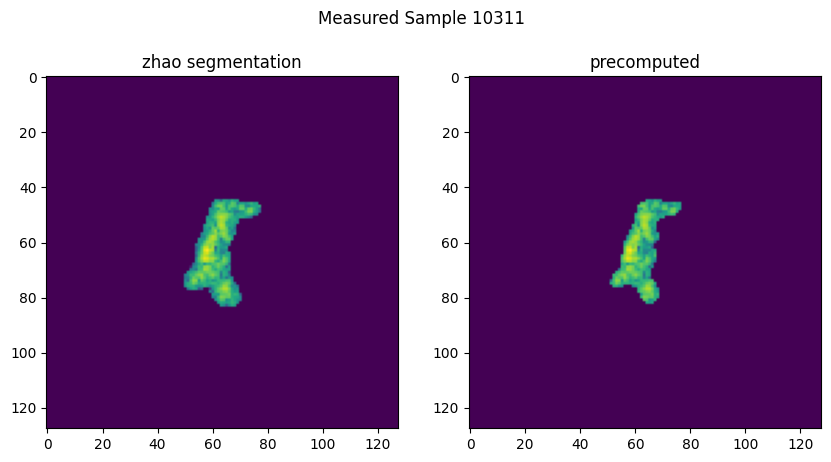

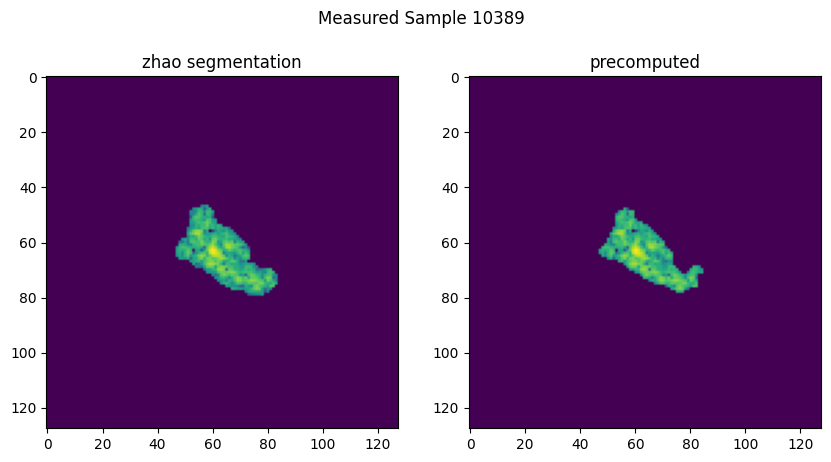

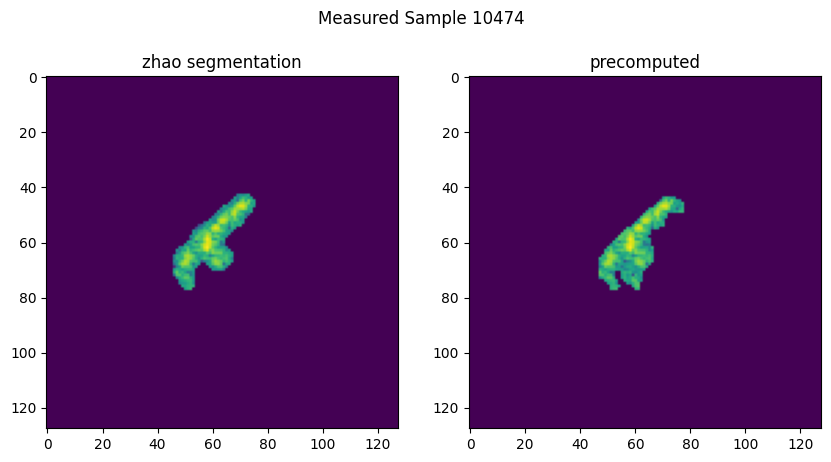

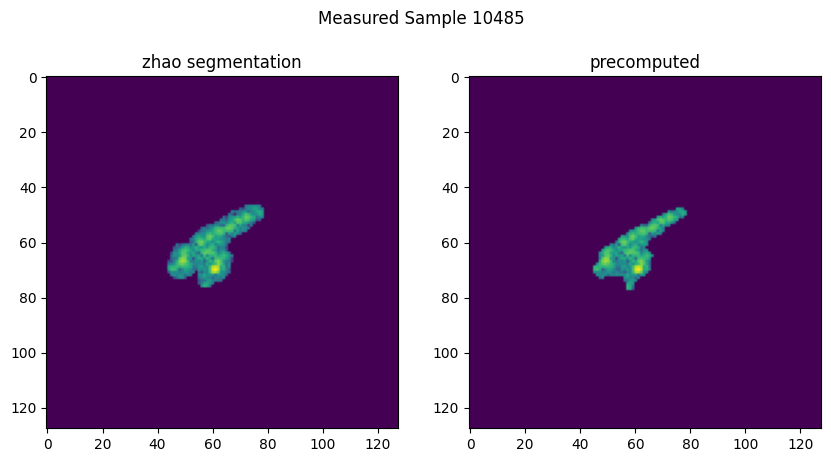

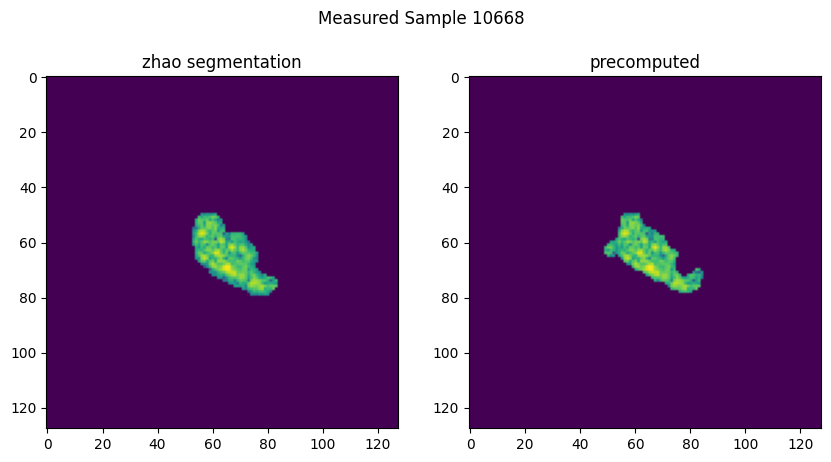

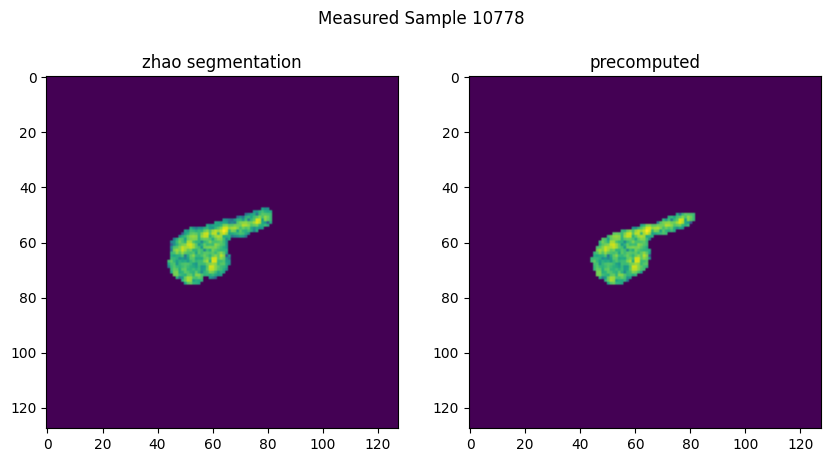

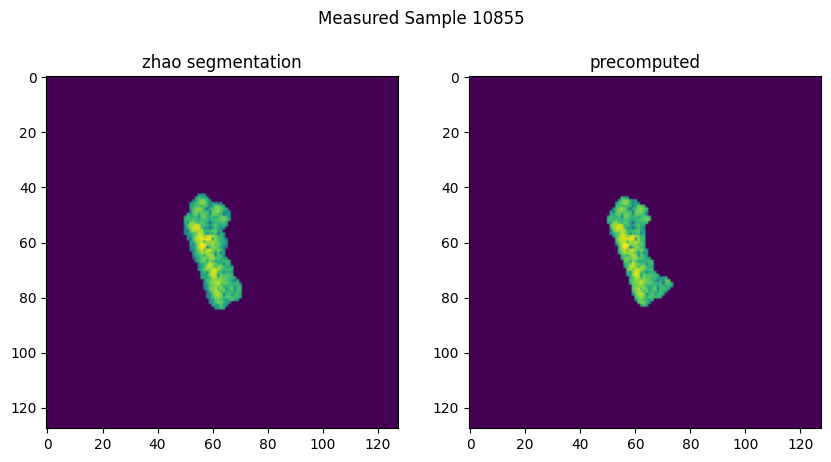

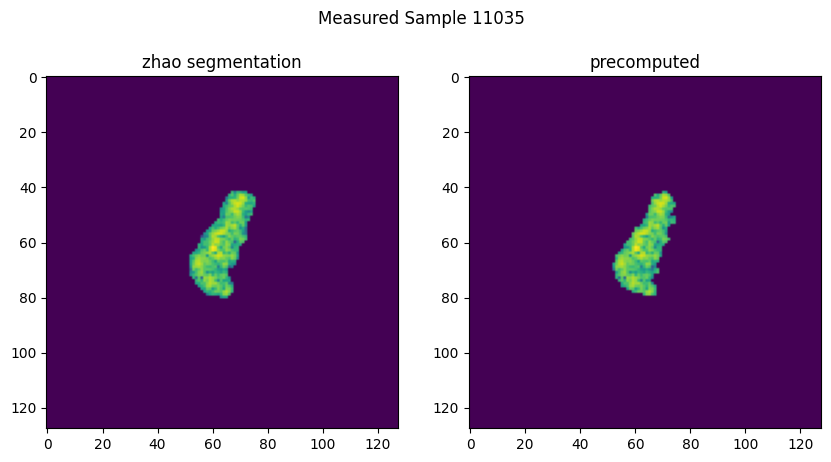

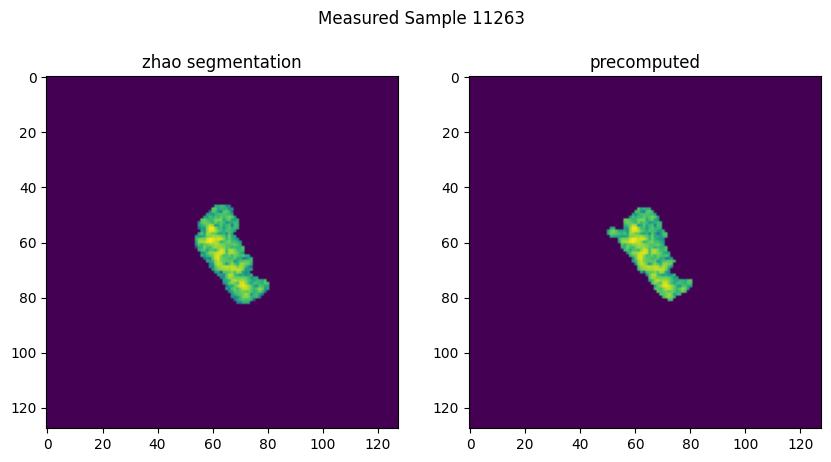

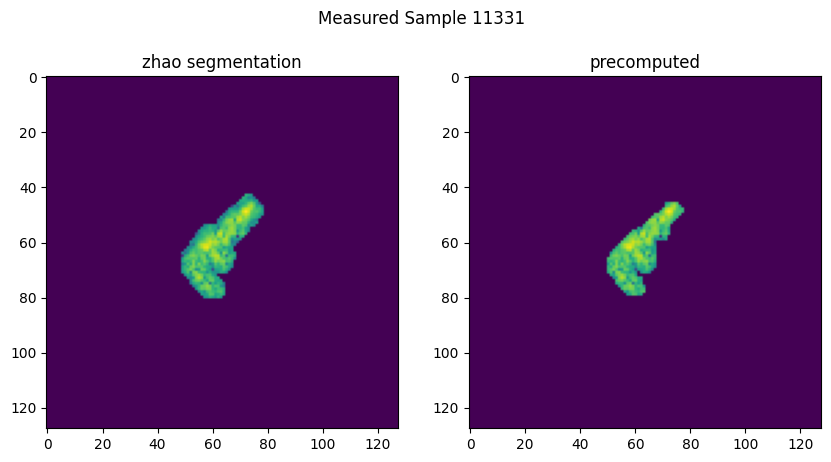

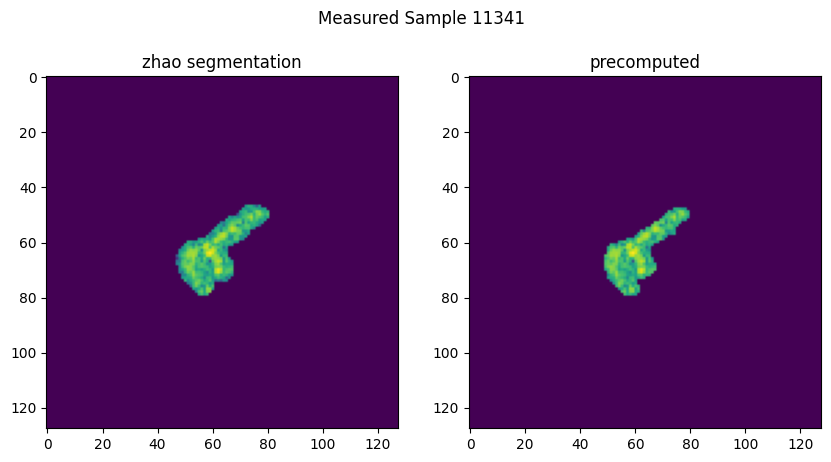

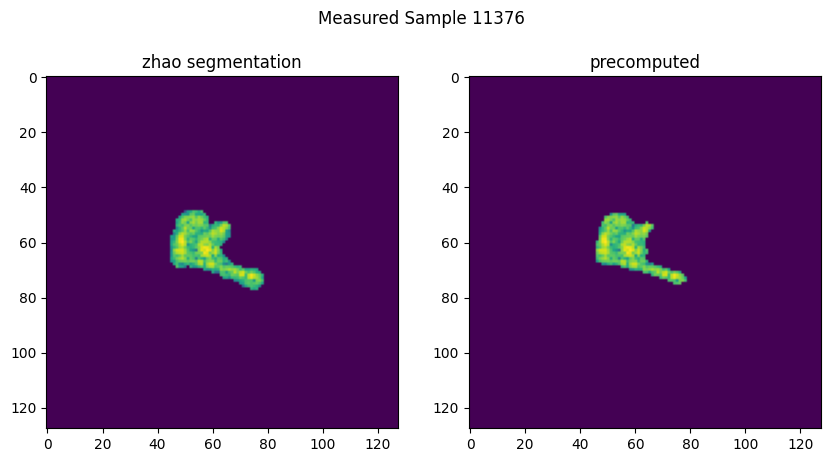

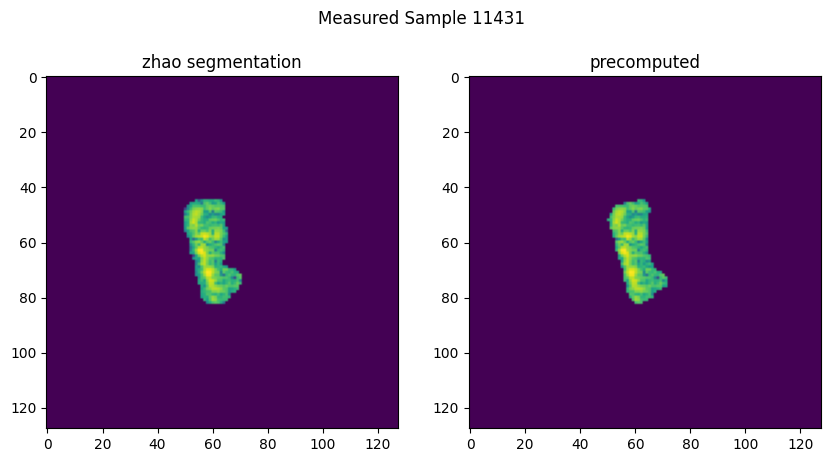

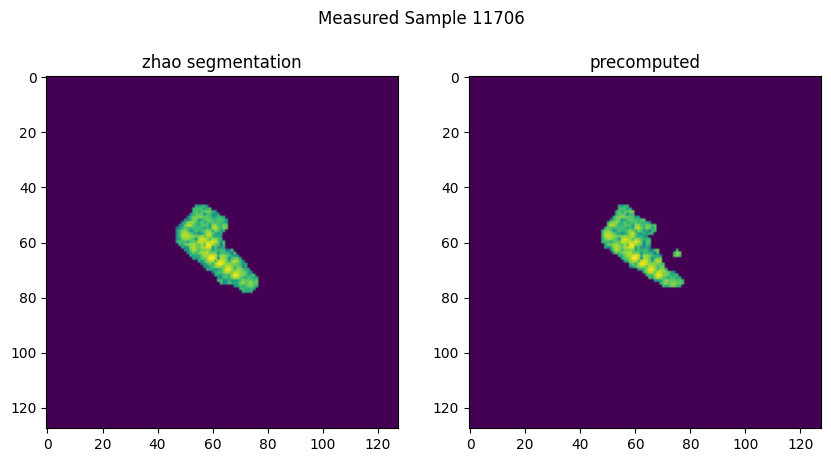

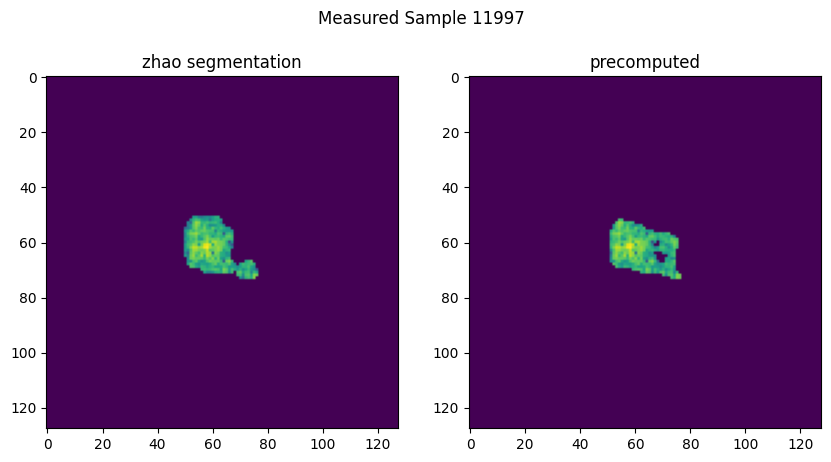

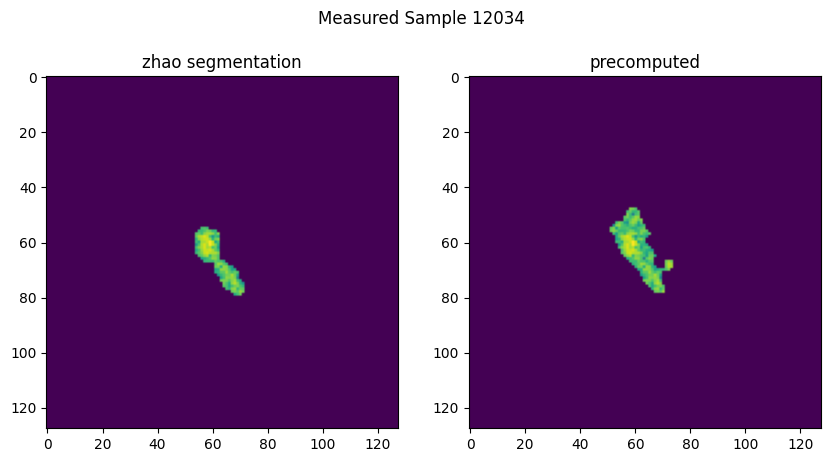

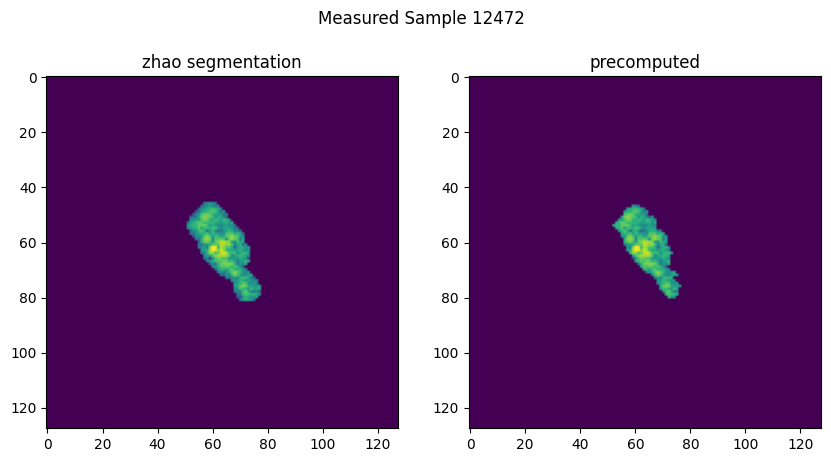

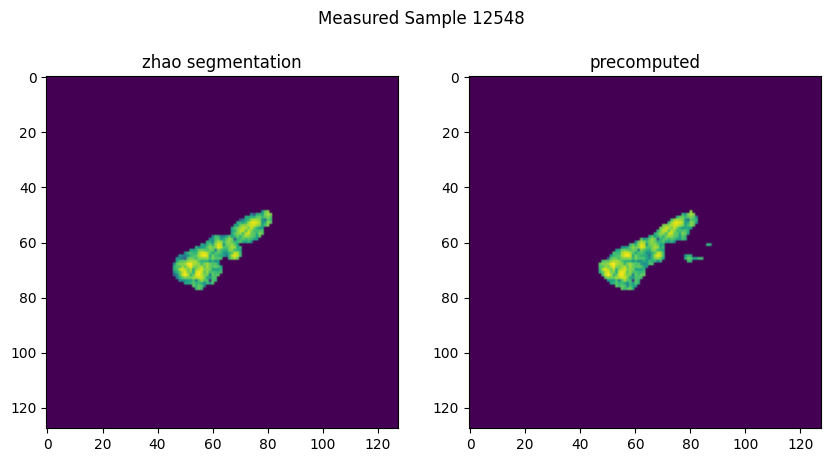

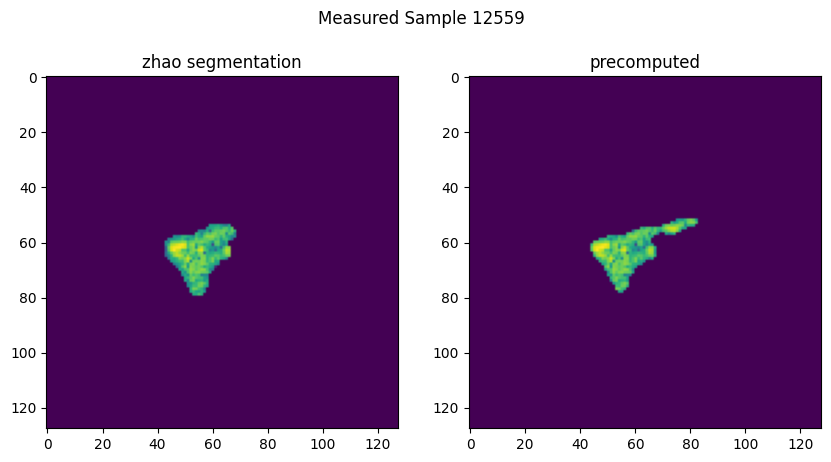

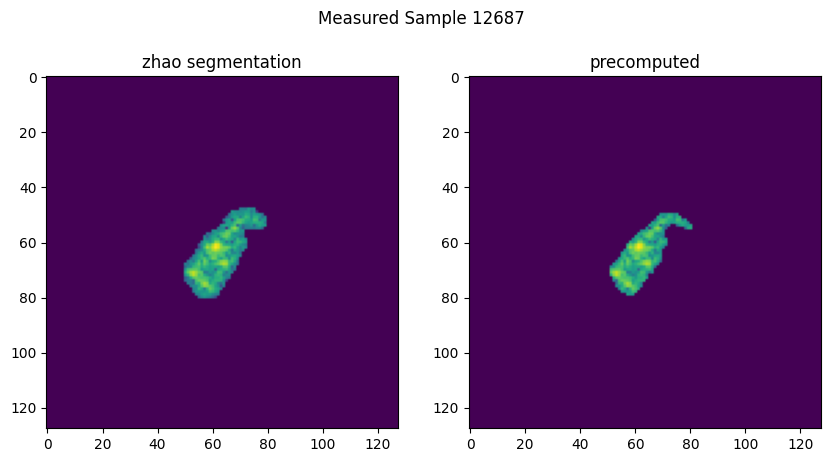

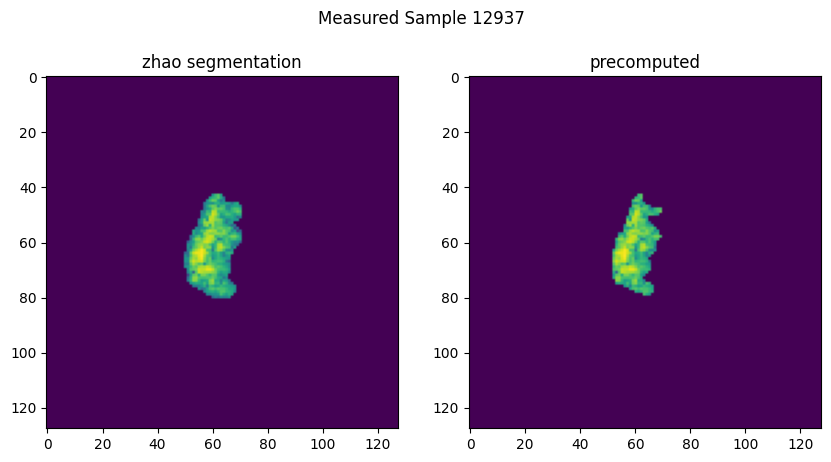

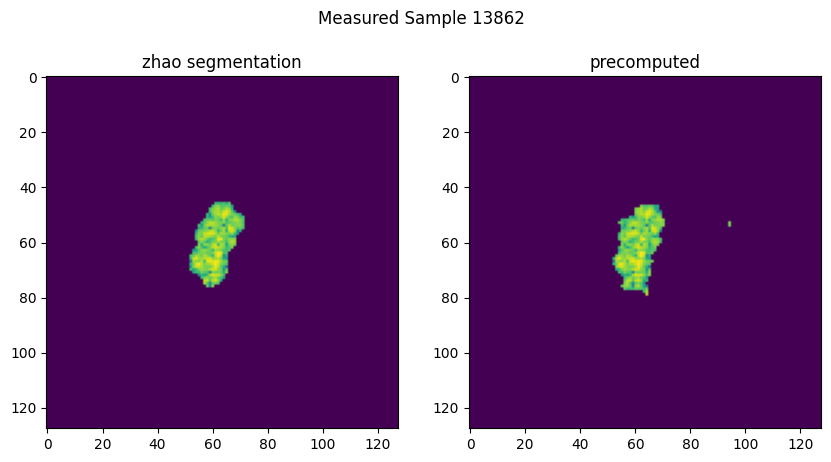

In [29]:
for i in [  154,   204,   248,   281,   485,   560,  1002,  1071,  1187,
        1313,  1566,  1666,  1878,  2004,  2050,  2262,  2330,  2392,
        2571,  2675,  2706,  2792,  2887,  2893,  2903,  3178,  3182,
        3555,  3556,  3769,  4174,  4197,  4660,  4826,  4994,  5126,
        5178,  5199,  5241,  5361,  5433,  5512,  5542,  5745,  5763,
        5795,  5887,  5938,  6217,  6292,  6402,  6632,  6635,  7069,
        7149,  7154,  7226,  7263,  7273,  7568,  7796,  7809,  7821,
        8113,  8164,  8477,  8896,  9311,  9335,  9430,  9513,  9651,
        9664,  9697,  9699, 10141, 10148, 10281, 10311, 10389, 10474,
       10485, 10668, 10778, 10855, 11035, 11263, 11331, 11341, 11376,
       11431, 11706, 11997, 12034, 12472, 12548, 12559, 12687, 12937,
       13862]:

    fig = plt.figure(figsize = (10, 5))
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(zhao_target_meas_ds[i][0][0].numpy())
    ax0.set_title("zhao segmentation")

    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(precomputed_target_meas_ds[i][0][0].numpy())
    ax1.set_title("precomputed")

    fig.suptitle(f"Measured Sample {i}")
    plt.show()

# Obtaining subsets

In [30]:
def extract_azimuth(path):
    match = re.search(r"azCenter_(\d{3})", path)
    if match:
        return int(match.group(1))
    return None

def filter_by_azimuth(dataset, allowed_angles):
    filtered = []
    ds_cp = copy.deepcopy(dataset)
    for path, label in dataset.samples:
        azim = extract_azimuth(path)
        if azim in allowed_angles:
            filtered.append((path, label))
    ds_cp.samples = filtered
    ds_cp.imgs = filtered
    ds_cp.targets = [label for _, label in filtered]
    return ds_cp

In [31]:
no_aug_synth_ds

Dataset DatasetFolderWithPath
    Number of datapoints: 5400
    Root location: /mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth
    StandardTransform
Transform: Compose(
           )

In [45]:
filter_by_azimuth(
    filter_by_elev(no_aug_synth_ds, {14, 15, 16}), 
    list(range(10, 80, 1))
).class_to_idx

{'2s1': 0,
 'bmp2': 1,
 'brdm_2': 2,
 'btr_60': 3,
 'btr_70': 4,
 'd7': 5,
 't62': 6,
 't72': 7,
 't72_straight': 8,
 'zil131': 9,
 'zsu_23_4': 10}

In [42]:
filter_by_azimuth(
    filter_by_elev(no_aug_synth_ds, {14, 15, 16}), 
    list(range(10, 80, 1))
).samples

[('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_010.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_011.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_012.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_013.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_014.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_015.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth/2s1/2s1_synth_elevDeg_015_azCenter_016.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_n

In [53]:
RemappedSubset(
    dataset = filter_by_azimuth(filter_by_elev(no_aug_synth_ds, {14, 15, 16}), list(range(10, 80, 1))),
    exclude_label= 8)